## Initialization

In [1]:
import os
import collections
import numpy as np
import struct
import argparse
import json
import cv2
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from PIL import Image, ImageDraw
import imageio.v2 as imageio  # Import for GIF creation
import matplotlib.cm as cm  # For consistent colormap handling
from matplotlib import colormaps
from matplotlib.lines import Line2D
from collections import defaultdict
import time

## Read model

In [2]:
import read_write_model as rwm
cameras, images, points3D = rwm.read_model(
        path=r'frames_8dir_turn/sparse', ext=".bin"
)

output_dir = r'frames_8dir_turn/outputs/'

## Data Structure

### Bounding Box

In [24]:
image_id = 1  # Replace with your image ID

### Images
Image list with two lines of data per image:

   IMAGE_ID, QW, QX, QY, QZ, TX, TY, TZ, CAMERA_ID, NAME

   POINTS2D[] as (X, Y, POINT3D_ID)

In [25]:
images[1] ## Images data format

Image(id=1, qvec=array([ 9.84696161e-01,  2.40150389e-02, -1.72616059e-01, -6.66963780e-04]), tvec=array([1.89597263, 0.28318652, 5.45046974]), camera_id=1, name='0037.png', xys=array([[ 13.63707256,   4.64662266],
       [ 16.72404099,   3.52468204],
       [ 21.7323761 ,   6.56088495],
       ...,
       [ 76.66609192, 132.59338379],
       [312.34680176, 244.39730835],
       [718.63220215, 335.28494263]]), point3D_ids=array([   -1,    -1,    -1, ...,    -1,    -1, 25030]))

In [26]:
a = images[1].xys[1]
index_a = np.where(images[1].xys == a)[0]
images[1].point3D_ids[index_a]

array([-1, -1])

### 3D Points
3D point list with one line of data per point:

   POINT3D_ID, X, Y, Z, R, G, B, ERROR, TRACK[] as (IMAGE_ID, POINT2D_IDX)

   POINT2D_IDX defines the zero-based index of the keypoint in the images.txt file.

In [27]:
points3D[1] ## 3D Points data format

Point3D(id=1, xyz=array([ 6.09830887, -2.67375558,  1.97869837]), rgb=array([104, 130, 147]), error=array(0.57006147), image_ids=array([ 22, 370,  27,  25,  28,  29,  30,  19,  16,  15,  31,  32,  33,
        43, 285, 369]), point2D_idxs=array([  29, 2077,   19, 1727,   30,   44,   72,   18,   71,   76,  106,
        154,  233,  103,   29,   52]))

### List all 3D Point ids that were generated in image i (1)

In [3]:
indexed_3dpoints_in_image = {index: value for index, value in enumerate(images[1].point3D_ids) if value != -1}

# {internal image keypoint index: point3D_id)
indexed_3dpoints_in_image

{103: 14857,
 122: 4766,
 123: 6575,
 151: 25558,
 160: 14858,
 161: 26607,
 163: 24892,
 166: 8751,
 170: 6184,
 171: 24942,
 172: 5437,
 173: 62377,
 174: 60454,
 175: 8656,
 176: 25401,
 177: 6574,
 178: 5926,
 179: 4776,
 180: 6493,
 181: 8093,
 182: 5059,
 183: 60476,
 184: 4770,
 191: 2963,
 225: 27273,
 226: 27535,
 229: 4794,
 230: 4795,
 231: 5147,
 232: 8321,
 234: 7909,
 240: 50272,
 241: 45904,
 242: 311,
 243: 4486,
 244: 4309,
 245: 5156,
 246: 14335,
 247: 14847,
 248: 3461,
 249: 26582,
 250: 15031,
 251: 89,
 253: 13653,
 259: 14860,
 260: 26502,
 264: 13566,
 265: 14861,
 266: 8864,
 267: 13952,
 268: 8866,
 269: 14666,
 271: 8807,
 273: 8814,
 274: 8897,
 283: 14168,
 284: 14862,
 296: 27614,
 309: 5935,
 312: 55834,
 313: 8107,
 314: 6824,
 315: 4247,
 317: 26773,
 318: 14463,
 319: 3780,
 321: 3903,
 322: 3753,
 325: 14863,
 326: 7967,
 327: 14493,
 329: 4090,
 330: 2741,
 333: 3576,
 336: 6296,
 339: 8511,
 340: 2673,
 341: 3298,
 342: 36283,
 343: 2097,
 344: 95,

### Get all 2D Point Index detected in image i (1) per 3D Point

In [29]:
points2d_idx=[num for num in points3D[1].point2D_idxs] # this only refers to the first 3D point. so this is probably wrong
points2d_idx

[29, 2077, 19, 1727, 30, 44, 72, 18, 71, 76, 106, 154, 233, 103, 29, 52]

In [30]:
indices = [index for index, value in indexed_3dpoints_in_image.items() if value in points2d_idx]
points=images[1].xys[indices]
points

array([[982.1060791 , 219.88482666],
       [976.58789062, 240.58599854],
       [985.3223877 , 226.80708313]])

In [31]:
indices = [index for index, value in indexed_3dpoints_in_image.items()]
points=images[1].xys[indices]
points

array([[116.52547455, 117.92182159],
       [537.23486328, 127.23692322],
       [542.09472656, 126.56700897],
       ...,
       [951.00115967, 149.37997437],
       [407.77893066, 317.60787964],
       [718.63220215, 335.28494263]])

### Load Mask

In [3]:
mask_name = '0037'
mask_img_np = np.load(os.path.join(output_dir, mask_name + '_mask.npy'))

In [33]:
# Function to check if a point is within any of the masks
def check_point_in_masks(x, y):
    # Get the mask number at the given point
    mask_number = mask_img_np[y, x]  # Note: (y, x) because numpy arrays are row-major

    if mask_number == 0:
        return "The point is not within any mask."
    else:
        return f"The point ({x}, {y}) is within the mask number {mask_number}."

# Example usage

# for point in points:
#     point_x, point_y = np.round(point).astype(int) # Replace with the actual y-coordinate
#     point_in_frame_segment_id = check_point_in_masks(point_x, point_y)
#     print(point_in_frame_segment_id)

### Test for One Image

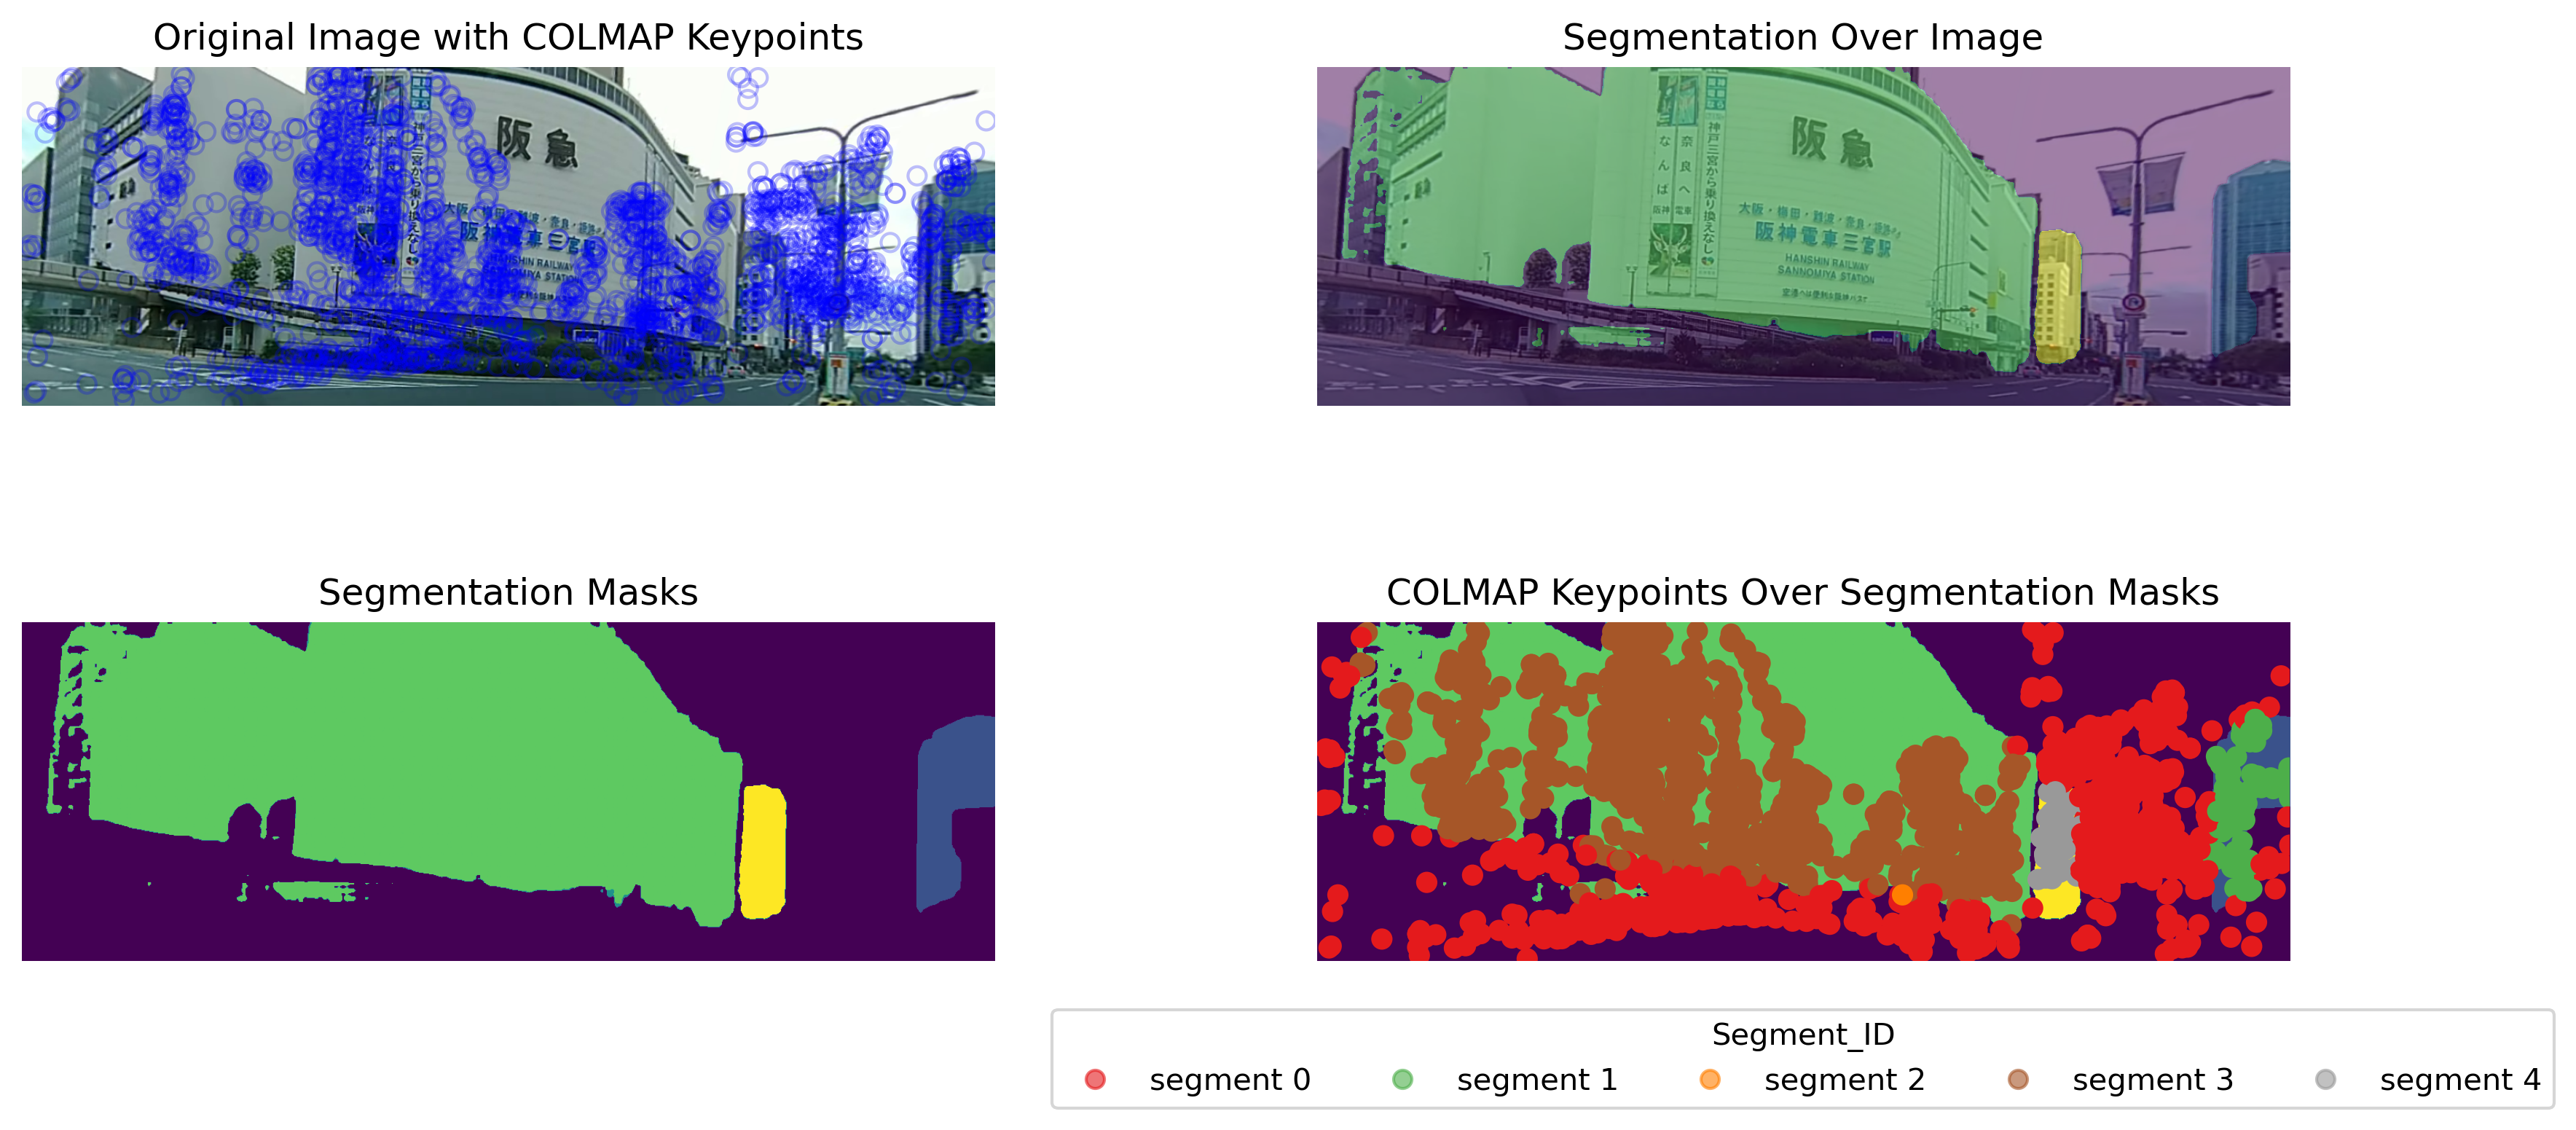

In [138]:

# Create a figure and a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(12, 6), dpi = 300)

# Flatten the array of subplots
axs = axs.flatten()

image = Image.open(os.path.join(r'frames_8dir_turn/', '0113' + '.png'))
mask_img_np = np.load(os.path.join(output_dir, '0113' + '_mask.npy'))

# Display the image
axs[0].imshow(image)  # Replace 'image' with your image variable
axs[0].scatter(points[:,0],points[:,-1],alpha=0.25, facecolors='none',edgecolors='blue', marker='o')
axs[0].set_title('Original Image with COLMAP Keypoints')
axs[0].axis('off')

# Display segmentation over the image
axs[1].imshow(image)  # Replace 'image' with your image variable
axs[1].imshow(mask_img_np, alpha = 0.5)  # Replace 'segmentation' with your segmentation variable
axs[1].set_title('Segmentation Over Image')
axs[1].axis('off')

# Display segmentation masks only
axs[2].imshow(mask_img_np)  # Replace 'segmentation' with your segmentation variable
axs[2].set_title('Segmentation Masks')
axs[2].axis('off')

height, width = mask_img_np.shape
point_x = np.clip((np.round(points[:, 0])), 0, width - 1).astype(int)
point_y = np.clip((np.round(points[:,-1])), 0, height - 1).astype(int)
# plt.figure()

color=mask_img_np[point_y, point_x]
num_segment = len(np.unique(color))

# Display detection keypoints over the image
axs[3].imshow(mask_img_np)
axs[3].set_title('COLMAP Keypoints Over Segmentation Masks')
axs[3].axis('off')

scatter = axs[3].scatter(points[:,0],points[:,-1],c=color,cmap='Set1')
handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)
legend_labels = [f'segment {i}' for i in range(num_segment)]
axs[3].legend(handles, legend_labels, title="Segment_ID",bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=6)
#plt.tight_layout(rect=[0, 0, 0.75, 1])  # Adjust layout to make room for the legend
# Adjust layout
fig.tight_layout()
# plt.show()
fig.savefig('high_res_plot.png', dpi=300)


## Assign 3D point per image and segment
#### Added dilation to make building masks clearer and less overlap etc. 

In [ ]:
apply_dilation = False  # Toggle for applying dilation
dilation_kernel_size = 3  # Kernel size for dilation (must be odd)

points_data = {}

# Create a global color mapping from segment_id to RGBA color
all_segment_ids = set()
for i in list(images.keys()):
    img_name = os.path.splitext(images[i].name)[0]
    mask_img_np = np.load(os.path.join(output_dir, img_name + '_mask.npy'))
    all_segment_ids.update(np.unique(mask_img_np))

all_segment_ids = sorted(list(all_segment_ids))
num_segments = len(all_segment_ids)

# Choose colormap and sample fixed colors
cmap_base = colormaps.get_cmap('tab20')
colors = cmap_base(np.linspace(0, 1, num_segments))

# Final mapping: segment_id → RGBA color
segment_to_color = {seg_id: colors[i] for i, seg_id in enumerate(all_segment_ids)}

for i in list(images.keys()):
    indexed_3dpoints_in_image = {index: value for index, value in enumerate(images[i].point3D_ids) if value != -1}

    indices = [index for index, value in indexed_3dpoints_in_image.items()]
    points = images[i].xys[indices]

    # Get masks
    img_name = os.path.splitext(images[i].name)[0]
    mask_img_np = np.load(os.path.join(output_dir, img_name + '_mask.npy'))

    height, width = mask_img_np.shape

    if apply_dilation:
        kernel = np.ones((dilation_kernel_size, dilation_kernel_size), np.uint8)
        mask_img_np = cv2.dilate(mask_img_np, kernel, iterations=1)

    # Get all xy keypoints in image
    point_x = np.clip((np.round(points[:, 0])), 0, width - 1).astype(int)
    point_y = np.clip((np.round(points[:, -1])), 0, height - 1).astype(int)

    # Visualization
    plt.figure()
    plt.imshow(mask_img_np)

    segment_id = mask_img_np[point_y, point_x]

    # Use consistent RGBA colors from global map
    point_colors = np.array([segment_to_color[sid] for sid in segment_id])

    scatter = plt.scatter(points[:, 0], points[:, 1], c=point_colors)

    # Unique segment IDs in this image
    unique_ids = np.unique(segment_id)

    # Create matching legend entries using the same exact colors
    handles = [
        Line2D([], [], marker='o', linestyle='', color=segment_to_color[sid], label=f'segment {sid}')
        for sid in unique_ids
    ]

    plt.legend(handles=handles, title="Segment_ID", bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=6)
    plt.title(img_name)

    plt.savefig(os.path.join(output_dir, f'untracked_mask_with_keypoints_{i}.png'), bbox_inches='tight', dpi=300)

    plt.show()


    
    # plt.figure()
    # plt.imshow(mask_img_np)
    
    # segment_id = mask_img_np[point_y, point_x]
    # num_segment = len(np.unique(segment_id))
    # scatter = plt.scatter(points[:, 0], points[:, -1], c=segment_id, cmap='Set1')
    # handles, labels = scatter.legend_elements(prop="colors", alpha=0.6)
    # legend_labels = [f'segment {i}' for i in range(num_segment)]
    # plt.legend(handles, legend_labels, title="Segment_ID", bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol=6)
    # plt.title(img_name)
    # plt.show()  # For interactive viewing

    # Prepare data for saving
    list1 = list(indexed_3dpoints_in_image.values())
    points_data[img_name] = [[list1[i], points[i], segment_id[i]] for i in range(len(list1))]
    
    print(' '.join(['working image', str(i), 'out of', str(len(images.keys()))]))
   
    plt.close()

# Save File
print("Finished working. Saving...")
with open('point_3d_indexed_with_segments.pkl', 'wb') as file:
    pickle.dump(points_data, file)


# Load Saved Data

In [4]:
with open('point_3d_indexed_with_segments.pkl', 'rb') as file: 
    point_3d_loaded = pickle.load(file)


#### Format:  [3D Point name, xy in image, segment id]

In [5]:
point_3d_loaded['0037']

[[14857, array([116.52547455, 117.92182159]), 2],
 [4766, array([537.23486328, 127.23692322]), 1],
 [6575, array([542.09472656, 126.56700897]), 1],
 [25558, array([432.91082764, 143.49549866]), 1],
 [14858, array([453.28317261, 143.01332092]), 1],
 [26607, array([479.11474609, 128.32397461]), 1],
 [24892, array([457.23217773, 144.20951843]), 1],
 [8751, array([500.56668091, 142.20878601]), 1],
 [6184, array([501.4564209 , 147.90182495]), 1],
 [24942, array([504.40997314, 146.25952148]), 1],
 [5437, array([504.40997314, 146.25952148]), 1],
 [62377, array([506.50436401, 148.58383179]), 1],
 [60454, array([501.17672729, 157.66880798]), 1],
 [8656, array([501.17672729, 157.66880798]), 1],
 [25401, array([515.05780029, 141.2322998 ]), 1],
 [6574, array([515.05780029, 141.2322998 ]), 1],
 [5926, array([517.77410889, 143.7046051 ]), 1],
 [4776, array([525.81237793, 143.12597656]), 1],
 [6493, array([536.6449585 , 130.09280396]), 1],
 [8093, array([539.26849365, 129.58312988]), 1],
 [5059, arr

### 3D Points in the Image, divided according to segment ID.
So, per Image we can list the 3D points associated with that segment ID.

In [6]:
points_3d_in_image = {}
for i in list(images.keys()):

    img_name = os.path.splitext(images[i].name)[0]

    if img_name not in points_3d_in_image:
        points_3d_in_image[img_name] = {}
    num_of_segments = len(np.unique([entry[2] for entry in point_3d_loaded[img_name]]))
   
    for j in range(num_of_segments):
        points_3d_in_image[img_name][j]= [entry[0] for entry in point_3d_loaded[img_name] if entry[2] == j]
        
    # ind = np.argmax(np.array([len(points_3d_1[img_name]) for i in range(len(points_3d_1))]))
    # big_seg_1 = points_3d_1[ind]



### Image X, 3D points in segment Y:
Data access for 3d points in [image][segment]

In [18]:
print(points_3d_in_image.keys())

dict_keys(['0037', '0038', '0039', '1758', '0040', '0041', '0042', '0043', '0044', '0045', '0046', '0047', '0048', '0049', '0050', '0051', '0052', '0053', '0054', '0055', '0056', '0057', '0058', '0059', '0060', '0095', '0096', '0097', '0098', '0099', '0100', '0101', '0102', '0103', '0104', '0105', '0106', '0107', '0108', '0109', '0110', '0111', '0112', '0113', '0114', '0115', '0116', '0117', '0118', '0119', '0120', '0121', '0122', '0123', '0124', '0125', '1762', '0126', '0127', '1756', '0128', '0129', '0130', '0131', '1760', '0132', '0133', '0134', '0135', '0136', '0137', '0138', '0139', '0140', '0141', '0142', '0143', '0144', '0145', '0227', '0228', '0229', '0230', '0231', '0232', '0233', '0234', '0235', '0236', '0237', '0238', '0239', '0240', '0241', '0242', '0243', '0244', '0245', '0246', '0247', '0248', '0249', '0250', '0251', '0252', '0253', '0254', '0255', '0256', '0257', '0258', '0259', '0260', '0261', '0262', '0263', '0264', '0265', '0420', '0421', '0422', '0423', '0424', '0425

In [9]:
len(points_3d_in_image['0037']) ## number of segments

5

### Calculate Intersect of segment 1 from Image i with segments of Image i+1

The goal is to find the next relevant segment. If enough similarity exists, both segments will be tagged same building ID.

In [6]:
def similarity_ratio(list1, list2):
    set1, set2 = set(list1), set(list2)
    intersection = set1 & set2
    similarity = len(intersection) / (len(set1) + len(set2) - len(intersection))
    return similarity * 100

In [7]:
# Similarity will get similarity %, intersect gives out point_ids
np.intersect1d(np.array(points_3d_in_image['0037'][1]),np.array(points_3d_in_image['0038'][1]))

array([ 1523,  1524,  3020,  3023,  3063,  4366,  4481,  4570,  4574,
        4641,  4642,  4694,  4698,  4726,  4736,  4766,  4768,  4770,
        4794,  4795,  4866,  4874,  4882,  4919,  4920,  4956,  4958,
        5003,  5006,  5012,  5013,  5036,  5076,  5168,  5170,  5175,
        5176,  5222,  5234,  5290,  5293,  5386,  5437,  5438,  5465,
        5504,  5524,  5534,  5788,  5819,  5833,  5854,  5926,  5935,
        6102,  6103,  6321,  6323,  6413,  6493,  6575,  6723,  6733,
        6751,  7004,  7368,  7824,  7909,  7910,  7975,  8023,  8068,
        8115,  8116,  8176,  8321,  8586,  8827,  8903,  8952, 13610,
       13666, 13720, 13734, 13866, 14055, 14060, 14097, 14098, 14286,
       14390, 14485, 14498, 14504, 14510, 14512, 14513, 14597, 14617,
       14672, 14673, 14688, 14719, 14720, 14721, 14741, 14784, 14786,
       14846, 14852, 14858, 14874, 14917, 14924, 14950, 14999, 15000,
       24892, 24942, 25010, 25151, 25309, 25452, 25558, 25740, 25965,
       26005, 26585,

In [12]:
similarity = similarity_ratio(points_3d_in_image['0037'][1],points_3d_in_image['0038'][1])
print(f"Similarity: {similarity:.2f}%")

Similarity: 50.96%


### Start working from biggest segment

start from biggest segment across all images
then move to second biggest segment across all images (which is not already associated)

In [13]:
big_ind = 0
big_len = 0
for image in list(images.keys()):
    image_name = os.path.splitext(images[image].name)[0]
    #  ind of biggest segment
    ind = np.argmax(np.array([len(points_3d_in_image[image_name][i]) for i in range(len(points_3d_in_image[image_name]))]))
    if ind != 0 and big_len < len(points_3d_in_image[image_name][ind]): 
        big_ind = ind
        big_seg = points_3d_in_image[image_name][ind]
        big_img = image_name
        big_len = len(points_3d_in_image[image_name][ind])


print('image: ',big_img,', segment: ', big_ind,', segment size: ',big_len ,'points, ',len(points_3d_in_image[big_img]), " segments in image")
print("size of segments:")
print([len(points_3d_in_image[big_img][i]) for i in range(len(points_3d_in_image[big_img]))])

image:  0112 , segment:  3 , segment size:  2137 points,  4  segments in image
size of segments:
[1119, 1, 107, 2137]


### Propegation
Now that we have the biggest segment, we need to go over all images and see what segments has similarity to this segment. we will tag all those segments with building_id=1. Then we would need to find second biggest untagged segment, etc.

#### Trying with biggest segment

In [9]:
building_seg = {}
# Iterate over all images starting from the start image
for image in list(images.keys()):
    image_name = os.path.splitext(images[image].name)[0]
    ind = np.argmax(np.array([len(points_3d_in_image[image_name][i]) for i in range(1,len(points_3d_in_image[image_name]))])) + 1
    similarity = similarity_ratio(points_3d_in_image[image_name][ind],points_3d_in_image[big_img][big_ind])
    # print(f"image: {image_name} segment: {ind}, similarity to big seg is {similarity:.2f}%")
    if similarity>5: # percent %
        if 1 in building_seg:
            building_seg[1].append([image_name, ind ,similarity])
        else:
            building_seg[1] = [image_name, ind, similarity]


#### Trying with highest similarity instead

In [10]:
building_seg = {}
# Iterate over all segments in the big image (reference image)
for build in range(len(points_3d_in_image[big_img])):
    for image in list(images.keys()):
        image_name = os.path.splitext(images[image].name)[0]

        # Calculate similarity between the current segment in big_img and all segments in image_name
        similarity = [
            similarity_ratio(points_3d_in_image[image_name][i], points_3d_in_image[big_img][build]) 
            for i in range(len(points_3d_in_image[image_name]))
        ]

        # Find the segment in image_name with the highest similarity
        best_match_index = np.argmax(similarity) # +1 because argmax is 0-based but similarity ignores backgrounds
        best_similarity = similarity[best_match_index]

        # Only record segments with similarity above a threshold
        if best_similarity > 5:  # percent
            if build in building_seg:
                building_seg[build].append([image_name, best_match_index, best_similarity])
            else:
                building_seg[build] = [[image_name, best_match_index, best_similarity]]


In [11]:
print("number of buildings:", len(building_seg))
print("image number, segment number, similarity index(%)")
building_seg[0]
print(type(building_seg))
print(type(building_seg[0]))

number of buildings: 4
image number, segment number, similarity index(%)
<class 'dict'>
<class 'list'>


Text(0, 0.5, '%')

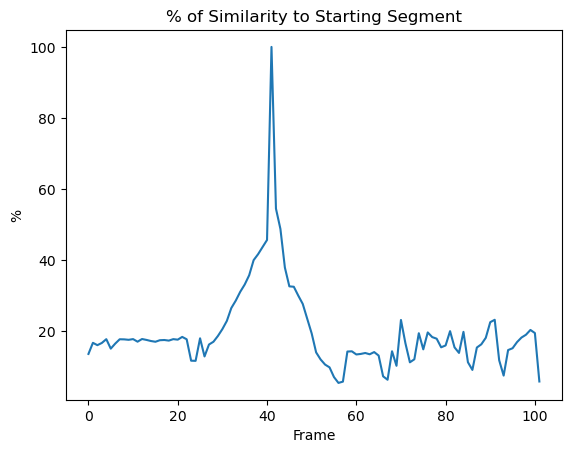

In [79]:
simis = [sim[2] for sim in building_seg[3]]
plt.figure()
plt.plot(simis)
plt.title('% of Similarity to Starting Segment')

# Label the x-axis
plt.xlabel('Frame')

# Label the y-axis
plt.ylabel('%')

## Propagating Refrence Image

In [11]:
def find_largest_segment(points_3d_in_image, tracked_segments):
    largest_segment = None
    largest_size = 0
    largest_image = None

    for image_name in points_3d_in_image.keys():
        for segment_id, points in points_3d_in_image[image_name].items():
            if segment_id == 0:
                continue
            if (image_name, segment_id) not in tracked_segments and len(points) > largest_size:
                largest_segment = segment_id
                largest_size = len(points)
                largest_image = image_name
    return largest_image, largest_segment, largest_size


def track_segments(points_3d_in_image, similarity_threshold=5):
    tracked_segments = set()
    building_seg = {}
    reference_segments = {}  # Stores the fixed reference segment for each building
    current_building_id = 0

    while True:
        # Find the largest untracked segment
        largest_image, largest_segment, largest_size = find_largest_segment(points_3d_in_image, tracked_segments)
        if not tracked_segments:
            print('image: ', largest_image, ', segment: ', largest_segment, ', segment size: ', largest_size, 'points, ',
                  len(points_3d_in_image[largest_image]), " segments in image")
            print("size of segments:")
            print([len(points_3d_in_image[largest_image][i]) for i in range(len(points_3d_in_image[largest_image]))])
        if largest_image is None or largest_segment is None:
            print("No largest segment found. Exiting loop.")
            break

        print(f"Tracking Building {current_building_id}: Image={largest_image}, Segment={largest_segment}, Size={largest_size}")

        # Set the reference segment (fixed for the entire tracking process)
        reference_segments[current_building_id] = points_3d_in_image[largest_image][largest_segment]
        building_seg[current_building_id] = [[largest_image, largest_segment, 100.0]]
        tracked_segments.add((largest_image, largest_segment))

        for image_name in points_3d_in_image.keys():
            # print(f"Processing Image: {image_name}")
            matched_segments = set()
            for segment_id, points in points_3d_in_image[image_name].items():
                if segment_id == 0 or (image_name, segment_id) in tracked_segments:
                    continue
                similarity = similarity_ratio(reference_segments[current_building_id], points)  # Fixed reference
                if similarity > similarity_threshold:
                    building_seg[current_building_id].append([image_name, segment_id, similarity])
                    matched_segments.add((image_name, segment_id))

            tracked_segments.update(matched_segments)

        current_building_id += 1

    return building_seg, reference_segments


def filter_and_reassign(building_seg, reference_segments, points_3d_in_image, min_points=10, min_segments=4):
    filtered_buildings = {}
    for building_id, segments in building_seg.items():
        total_points = set()
        unique_images = set()
        for image_name, segment_id, _ in segments:
            total_points.update(points_3d_in_image[image_name][segment_id])
            unique_images.add(image_name)

        if len(total_points) >= min_points and len(unique_images) >= min_segments:
            filtered_buildings[building_id] = segments

    return filtered_buildings


def merge_buildings(building_seg, reference_segments, points_3d_in_image, similarity_threshold=80):
    merged_buildings = {}
    merged_references = {}

    # Track which buildings are already merged
    merged_ids = set()

    # Helper function to merge two buildings
    def merge_two_buildings(bid1, bid2):
        merged_segments = building_seg[bid1] + building_seg[bid2]

        # Collect all 3D points across all segments in both buildings
        merged_reference = set()
        for img, seg, _ in merged_segments:
            merged_reference.update(points_3d_in_image[img][seg])

        return merged_segments, list(merged_reference)

    current_building_id = 0

    # Iterate through all building pairs
    for bid1 in building_seg.keys():
        if bid1 in merged_ids:
            continue

        merged_segments = building_seg[bid1]

        # Collect initial reference points for the current building
        merged_reference = set()
        for img, seg, _ in merged_segments:
            merged_reference.update(points_3d_in_image[img][seg])

        for bid2 in building_seg.keys():
            if bid1 == bid2 or bid2 in merged_ids:
                continue

            # Collect reference points for the second building
            reference_bid2 = set()
            for img, seg, _ in building_seg[bid2]:
                reference_bid2.update(points_3d_in_image[img][seg])

            # Calculate similarity between combined 3D points
            similarity = similarity_ratio(merged_reference, reference_bid2)

            if similarity >= similarity_threshold:
                # Merge bid2 into bid1
                merged_segments, merged_reference = merge_two_buildings(bid1, bid2)
                merged_ids.add(bid2)

        # Store the merged building
        merged_buildings[current_building_id] = merged_segments
        merged_references[current_building_id] = list(merged_reference)

        current_building_id += 1

    return merged_buildings, merged_references



In [12]:
# Usage
building_seg, reference_segments = track_segments(points_3d_in_image)
reassigned_buildings = filter_and_reassign(building_seg, reference_segments, points_3d_in_image)

# Output results
print("Created " + str(len(reassigned_buildings)) + " buildings")

total_points = 0  # To track the total number of 3D points across all buildings
total_segments = 0  # To track the total number of segments (frames) across all buildings

for bid, segments in reassigned_buildings.items():
    num_points = sum(len(points_3d_in_image[img][seg]) for img, seg, _ in segments)  # Count 3D points
    total_points += num_points

    segments_in_building = len(set((image_name, segment_id) for image_name, segment_id, _ in segments))
    total_segments += segments_in_building

    print(f"Building {bid} has {num_points} points and spans {segments_in_building} segments")

# Calculate averages
num_buildings = len(reassigned_buildings)
if num_buildings > 0:
    avg_points_per_building = total_points / num_buildings
    avg_segments_per_building = total_segments / num_buildings

    print(f"Average number of 3D points per building: {avg_points_per_building:.2f}")
    print(f"Average number of segments (frames) per building: {avg_segments_per_building:.2f}")
else:
    print("No buildings were created, so averages cannot be calculated.")

# Merge similar buildings
merged_buildings, merged_references = merge_buildings(reassigned_buildings, reference_segments, points_3d_in_image)

print("After merging, created", len(merged_buildings), "buildings")

total_points = sum(
    sum(len(points_3d_in_image[img][seg]) for img, seg, _ in segments)
    for segments in merged_buildings.values()
)

print("Total points in merged buildings:", total_points) 

# Saving JSON data

json_out_path = os.path.join(output_dir, "tracking_results.json") # Path for the JSON file

# Write JSON
with open(json_out_path, "w") as f:
    json.dump(merged_buildings, f, indent=2)

print(f"Saved tracking results to {json_out_path}")
    
# Display merged building stats
for bid, segments in merged_buildings.items():
    num_points = sum(len(points_3d_in_image[img][seg]) for img, seg, _ in segments)
    num_segments = len(set((img, seg) for img, seg, _ in segments))

    print(f"Merged Building {bid}: {num_points} points, {num_segments} segments")

with open('merged_buildings_dict.pkl', 'wb') as f:
    pickle.dump(merged_buildings, f)
        


image:  0112 , segment:  3 , segment size:  2137 points,  4  segments in image
size of segments:
[1119, 1, 107, 2137]
Tracking Building 0: Image=0112, Segment=3, Size=2137
Tracking Building 1: Image=1593, Segment=6, Size=1328
Tracking Building 2: Image=0799, Segment=1, Size=1302
Tracking Building 3: Image=1136, Segment=1, Size=1255
Tracking Building 4: Image=0129, Segment=1, Size=1216
Tracking Building 5: Image=1436, Segment=2, Size=1148
Tracking Building 6: Image=0252, Segment=1, Size=922
Tracking Building 7: Image=1583, Segment=1, Size=902
Tracking Building 8: Image=0142, Segment=1, Size=817
Tracking Building 9: Image=0445, Segment=5, Size=744
Tracking Building 10: Image=1159, Segment=1, Size=725
Tracking Building 11: Image=1623, Segment=3, Size=550
Tracking Building 12: Image=0781, Segment=1, Size=506
Tracking Building 13: Image=0132, Segment=4, Size=481
Tracking Building 14: Image=0103, Segment=1, Size=477
Tracking Building 15: Image=1754, Segment=1, Size=414
Tracking Building 16: 

### Load Merged Buildings dict

In [7]:
with open('merged_buildings_dict.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
merged_buildings = loaded_dict
merged_buildings

{0: [['0112', 3, 100.0],
  ['0037', 3, 15.830273357813137],
  ['0038', 3, 16.646415552855405],
  ['0039', 2, 15.988945913936044],
  ['0040', 2, 16.608050019538883],
  ['0041', 2, 17.67716535433071],
  ['0042', 2, 15.007961783439491],
  ['0043', 2, 16.427432216905903],
  ['0044', 2, 17.647058823529413],
  ['0045', 2, 17.617384555684907],
  ['0046', 3, 17.494089834515368],
  ['0047', 4, 17.69352290679305],
  ['0048', 3, 16.967084639498434],
  ['0049', 2, 17.718068535825545],
  ['0050', 3, 17.46402178140801],
  ['0051', 3, 17.152858809801632],
  ['0052', 3, 16.946505271378367],
  ['0053', 2, 17.379364456649665],
  ['0054', 2, 17.43869209809264],
  ['0055', 2, 17.26923076923077],
  ['0056', 3, 17.681498829039814],
  ['0057', 3, 17.537022603273577],
  ['0058', 3, 18.312040263259778],
  ['0059', 3, 17.647058823529413],
  ['0096', 3, 17.92018419033001],
  ['0098', 2, 16.166466586634655],
  ['0099', 2, 16.949822204662187],
  ['0100', 2, 18.578161822466615],
  ['0101', 4, 20.51282051282051],
  

#### Convert segment-based tracking to MOT Style labels for validation

In [14]:
! python convert2mot.py \
  --tracking_json frames_8dir_turn/outputs/tracking_results.json \
  --annotations_dir frames_8dir_turn/outputs \
  --output_mot frames_8dir_turn/outputs/tracker_mot.txt

MOT-style tracking file generated at: frames_8dir_turn/outputs/tracker_mot.txt


In [51]:
from convert_SAM_to_CVAT11_v2 import *

convert_coco_to_cvat11(input_coco_path="frames_8dir_turn/outputs/annotations_tracking.json",
    output_xml_path="frames_8dir_turn/outputs/annotations_with_track2.xml"
)


CVAT 1.1 XML saved to frames_8dir_turn/outputs/annotations_with_track2.xml


In [52]:
from SAM_to_CVAT11 import convert_sam_tracking_to_cvat11

convert_sam_tracking_to_cvat11(
    tracking_data=merged_buildings,
    annotations_dir="frames_8dir_turn/outputs",
    images_dir="frames_8dir_turn",
    output_xml_path="frames_8dir_turn/outputs/CVAT_annotations_nonpersistent.xml"
)


CVAT 1.1 XML saved to frames_8dir_turn/outputs/CVAT_annotations_nonpersistent.xml


### Associate points from segments and create reverse lookup dictionary to find building index for points

In [61]:
# Create a dictionary that maps each building to a set of unique 3D point IDs.
building_points = {}

# Iterate over each building in merged_buildings (or use reassigned_buildings if desired)
for building_id, segments in merged_buildings.items():
    for item in segments:
        image_name, segment, similarity = item
        # Get the 3D points associated with this segment from the image.
        pts = points_3d_in_image[image_name][segment]
        
        # Initialize the building's set if it doesn't exist, or update it by taking a union.
        if building_id in building_points:
            building_points[building_id] = set(building_points[building_id]).union(pts)
        else:
            building_points[building_id] = set(pts)

# Optional: Print out stats about the buildings
print("Created " + str(len(building_points) - (1 if 0 in building_points else 0)) + " buildings, not including background")
# for bid, pts in building_points.items():
#     if bid == 0:
#         print("Background has " + str(len(pts)) + " points")
#     else:
#         print(f"Building {bid} has {len(pts)} unique points")

# Now create a reverse lookup dictionary mapping each point ID to its building ID.
point_to_building = {}
for building_id, pts in building_points.items():
    for pt in pts:
        point_to_building[pt] = building_id  # Each point maps to its building

# Define a function to look up the building index for a given 3D point ID.
def find_building_for_point(point):
    return point_to_building.get(point, None)

# Example usage:
point = 644  # Replace with the actual point ID you wish to look up
building_index = find_building_for_point(point)
if building_index is not None:
    print(f"Point {point} is in building {building_index}.")
else:
    print(f"Point {point} was not found in any building.")


Created 50 buildings, not including background
Point 644 was not found in any building.


### Reformat COLMAP dataset to have building_id attribute

We change points3D.txt to have the following format:

<pre>POINT3D_ID X Y Z R G B ERROR <span style="color:red">building_id</span> TRACKS </code>

In [63]:
write_all_data_to_single_file = True

if write_all_data_to_single_file:
    with open('frames_8dir_turn/sparse/points3D.txt', 'r') as infile, open('frames_8dir_turn/sparse/points3D_modified_v2.txt', 'w') as outfile:
        for line in infile:
            if line.startswith('#') or line.strip() == '':
                outfile.write(line)  # Copy header or blank lines
                continue
    
            parts = line.strip().split()
            building_id = find_building_for_point(int(parts[0]))
            if building_id is not None:
                new_line = ' '.join(parts[:8] + [str(building_id)] + parts[8:]) + '\n'
            else:
                building_id = 0
                new_line = ' '.join(parts[:8] + [str(building_id)] + parts[8:]) + '\n'
            outfile.write(new_line)
    # Convert txt to LAS
    txt_file = f"frames_8dir_turn/sparse/points3D_modified_v2.txt"
    %run txt2las_convert.py {txt_file}

Converting frames_8dir_turn/sparse/points3D_modified_v2.txt to LAS...
LAS file created at frames_8dir_turn/sparse/points3D_modified_v2.las


In [64]:
# Write to seperate txt files for each building

if not write_all_data_to_single_file:
    # Read the input file into memory
    with open('frames_8dir_turn/sparse/points3D.txt', 'r') as infile:
        lines = infile.readlines()
    
    # Prepare output files
    outfiles = {
        building_index: open(os.path.join('frames_8dir_turn/sparse/seperate_buildings', f'points3D_{building_index}.txt'), 'w')
        for building_index in reassigned_buildings.keys()
    }
    
    # Write headers to each output file
    for line in lines:
        if line.startswith('#') or line.strip() == '':
            for outfile in outfiles.values():
                outfile.write(line)  # Write headers to all files
            continue
        
        # Process non-header lines
        parts = line.strip().split()
        point_id = int(parts[0])
        building_id = find_building_for_point(point_id)
    
        if building_id is None:
            building_id = 0  # Default to 0 if no building found
    
        new_line = ' '.join(parts[:8] + [str(building_id)] + parts[8:]) + '\n'
        
        # Write to the appropriate output file
        if building_id in outfiles:
            outfiles[building_id].write(new_line)
    
    # Close all output files
    for outfile in outfiles.values():
        outfile.close()

            
    # Generate las files for txt files
    for building_index in reassigned_buildings.keys():
        txt_file = f"frames_8dir_turn/sparse/seperate_buildings/points3D_{building_index}.txt"
        # Call the conversion script with the file name
        %run txt2las_convert.py {txt_file}

In [65]:
# Convert LAS to potree format using PotreeConverter
if write_all_data_to_single_file:
    if os.name == "posix":
        ! PotreeConverter_mac/PotreeConverter/build/potreeconverter -i PotreeConverter_mac/PotreeConverter/build/points3D_modified.las -o potree_mac/potree/pointclouds/potree_format --generate-page building_classification
    elif os.name == "nt":
        ! PotreeConverter\\build\\Release\\potreeconverter.exe -i frames_8dir_turn\\sparse\\points3D_modified_v2.las -o potree\\pointclouds\\micware_new --generate-page building_classification


#threads: 28
#paths: 1

output attributes: 
name                              offset    size
position                               0      12
intensity                             12       2
return number                         14       1
number of returns                     15       1
classification                        16       1
scan angle rank                       17       1
user data                             18       1
point source id                       19       2
gps-time                              21       8
rgb                                   29       6
error                                 35       8
point_id                              43       4
building_id                           47       4
                                              51
cubicAABB: {
	"min": [-138.280000, -41.560000, -148.580000],
	"max": [162.640000, 259.360000, 152.340000],
	"size": [300.920000, 300.920000, 300.920000]
}
#points: 102'325
total file size: 4.9 MB
target directory: 'C:\Use

In [15]:
# Convert LAS to potree format using PotreeConverter for each building
if not write_all_data_to_single_file:
    for building_index in reassigned_buildings.keys():
        las_file = f"frames_8dir_turn/sparse/seperate_buildings/points3D_{building_index}.las"
        output_dir_mac = f"potree_mac/potree/pointclouds/micware_buildings/building_{building_index}"
        output_dir_win = f"potree\\pointclouds\\micware\\building_{building_index}"
    
        if os.name == "posix":  # macOS/Linux
            command = f"./PotreeConverter_mac/PotreeConverter/build/potreeconverter -i {las_file} -o {output_dir_mac} --generate-page building_{building_index}"
        elif os.name == "nt":  # Windows
            command = f"PotreeConverter\\build\\Release\\potreeconverter.exe -i {las_file} -o {output_dir_win} --generate-page building_{building_index}"
        
        # Execute the command
        print(f"Processing {las_file} to {output_dir}...")
        os.system(command)

Processing frames_8dir_turn/sparse/seperate_buildings/points3D_0.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_1.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_2.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_3.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_4.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_5.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_6.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_7.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_8.las to frames_8dir_turn/outputs/...
Processing frames_8dir_turn/sparse/seperate_buildings/points3D_9.las to frames_8dir_turn/ou

### Showing individual building tracking and adding Keypoints Overlay

In [23]:
def generate_color_mapping(keys):
    """
    Generate a reproducible distinct color mapping for each building key.
    """
    np.random.seed(42)
    colors = plt.cm.tab20(np.linspace(0, 1, len(keys)))
    return {key: color for key, color in zip(keys, colors)}

def annotate_building_segment(ax, mask_img, segment, building_id):
    """
    Annotate the segment on the given axes with the building ID and its center coordinates.
    """
    y_coords, x_coords = np.where(mask_img == segment)
    if len(x_coords) == 0 or len(y_coords) == 0:
        return
    center_x = np.mean(x_coords)
    center_y = np.mean(y_coords)
    annotation = f"{building_id}"
    ax.text(center_x, center_y, annotation, color='white', fontsize=10,
            ha='center', va='center',
            bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.3'))

def overlay_keypoints(ax, image_name, keypoints_data):
    """
    Overlay the 2D keypoints on the image, colored by their segment ID.
    """
    if image_name not in keypoints_data:
        return
    
    keypoints = np.array([entry[1] for entry in keypoints_data[image_name]])
    segments = np.array([entry[2] for entry in keypoints_data[image_name]])
    
    if keypoints.size == 0 or keypoints.ndim != 2 or keypoints.shape[1] < 2:
        return
    
    unique_segments = np.unique(segments)
    segment_colors = {seg: plt.cm.tab20(i / len(unique_segments)) for i, seg in enumerate(unique_segments)}
    
    for seg in unique_segments:
        mask = segments == seg
        ax.scatter(
            keypoints[mask, 0], keypoints[mask, 1],
            marker='x', color=segment_colors[seg], s=20,
            label=f'Segment {seg}'
        )
    
    ax.legend(loc='upper right', fontsize=8)

def process_images(building_data, output_prefix, overlay_keypoints_flag=False):
    """
    Process images and generate output files with different configurations.
    """
    previous_image_segments = {}
    id_changes = []
    
    for image_name in sorted(points_3d_in_image.keys()):
        print(f"Processing {output_prefix} image {image_name}")
        
        img_path = os.path.join('frames_8dir_turn', image_name + '.png')
        try:
            img = Image.open(img_path).convert("RGBA")
        except FileNotFoundError:
            print(f"Image file {img_path} not found, skipping.")
            continue
        
        mask_path = os.path.join(output_dir, image_name + '_mask.npy')
        try:
            mask_img_np = np.load(mask_path)
        except FileNotFoundError:
            print(f"Mask file {mask_path} not found, skipping.")
            continue
        
        mask_overlay = np.zeros((*mask_img_np.shape, 4), dtype=np.uint8)
        current_image_segments = {}
        
        for building_id, entries in building_data.items():
            if building_id == 0:
                continue
            for entry in entries:
                entry_image, segment, similarity = entry
                if entry_image == image_name and segment != 0:
                    building_color = (np.array(color_mapping[building_id][:3]) * 255).astype(np.uint8)
                    mask_overlay[mask_img_np == segment, :3] = building_color
                    mask_overlay[mask_img_np == segment, 3] = 200
                    current_image_segments[segment] = building_id
        
        if previous_image_segments:
            for segment, new_building_id in current_image_segments.items():
                old_building_id = previous_image_segments.get(segment)
                if old_building_id is not None and old_building_id != new_building_id:
                    id_changes.append((image_name, segment, old_building_id, new_building_id))
        previous_image_segments = current_image_segments
        
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img)
        ax.imshow(mask_overlay, alpha=0.5)
        
        for segment, building_id in current_image_segments.items():
            annotate_building_segment(ax, mask_img_np, segment, building_id)
        
        if overlay_keypoints_flag:
            overlay_keypoints(ax, image_name, point_3d_loaded)
        
        ax.set_title(f"{output_prefix} Image: {image_name}")
        ax.axis("off")
        
        output_name = f"{output_prefix}_tracked_{image_name}.png"
        output_path = os.path.join(output_dir, output_name)
        fig.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
        plt.close(fig)
        
        print(f"Saved {output_prefix} output for image {image_name} to {output_path}")
    
    if id_changes:
        print(f"Detected Building ID Changes in {output_prefix}:")
        for image_name, segment, old_id, new_id in id_changes:
            print(f"Image {image_name}: Segment {segment} changed from Building {old_id} to {new_id}")
    else:
        print(f"No Building ID changes detected in {output_prefix}.")
    
    tracked_files = sorted(
        [f for f in os.listdir(output_dir) if f.startswith(f'{output_prefix}_tracked_')],
        key=lambda x: int(x.split('_')[-1].split('.')[0])
    )
    images_list = [Image.open(os.path.join(output_dir, f)) for f in tracked_files]
    gif_path = os.path.join(output_dir, f'{output_prefix}_all_tracked_images.gif')
    images_list[0].save(gif_path, save_all=True, append_images=images_list[1:], optimize=True, duration=60, loop=0)
    print(f"GIF saved to {gif_path}")

# Load data
with open('point_3d_indexed_with_segments.pkl', 'rb') as file:
    point_3d_loaded = pickle.load(file)

color_mapping = generate_color_mapping(set(reassigned_buildings.keys()).union(set(merged_buildings.keys())))

# Run three versions
process_images(reassigned_buildings, "unmerged", overlay_keypoints_flag=False)
process_images(merged_buildings, "merged", overlay_keypoints_flag=False)
process_images(merged_buildings, "merged_with_keypoints", overlay_keypoints_flag=True)


Processing unmerged image 0037
Saved unmerged output for image 0037 to frames_8dir_turn/outputs/unmerged_tracked_0037.png
Processing unmerged image 0038
Saved unmerged output for image 0038 to frames_8dir_turn/outputs/unmerged_tracked_0038.png
Processing unmerged image 0039
Saved unmerged output for image 0039 to frames_8dir_turn/outputs/unmerged_tracked_0039.png
Processing unmerged image 0040
Saved unmerged output for image 0040 to frames_8dir_turn/outputs/unmerged_tracked_0040.png
Processing unmerged image 0041
Saved unmerged output for image 0041 to frames_8dir_turn/outputs/unmerged_tracked_0041.png
Processing unmerged image 0042
Saved unmerged output for image 0042 to frames_8dir_turn/outputs/unmerged_tracked_0042.png
Processing unmerged image 0043
Saved unmerged output for image 0043 to frames_8dir_turn/outputs/unmerged_tracked_0043.png
Processing unmerged image 0044
Saved unmerged output for image 0044 to frames_8dir_turn/outputs/unmerged_tracked_0044.png
Processing unmerged imag

ValueError: images do not match

### Individual Building Tracking

In [16]:
# Loop over buildings in merged_buildings
for building_id in merged_buildings:
    if building_id ==0:
        continue

    print(f"Processing building {building_id}")
    building_output_prefix = f"merged_building_{building_id}"
    building_images = []

    for image_name in sorted(points_3d_in_image.keys()):
        img_path = os.path.join('frames_8dir_turn', image_name + '.png')
        mask_path = os.path.join(output_dir, image_name + '_mask.npy')

        try:
            img = Image.open(img_path).convert("RGBA")
            mask_img_np = np.load(mask_path)
        except FileNotFoundError:
            print(f"Skipping {image_name}, file not found")
            continue

        # Create RGBA overlay
        overlay = np.zeros((*mask_img_np.shape, 4), dtype=np.uint8)

        # Find all segments for this building in this image
        building_segments = [
            segment for entry_image, segment, similarity in merged_buildings[building_id]
            if entry_image == image_name and segment != 0
        ]

        # Mask tracked building yellow
        for seg in building_segments:
            color = np.array(plt.cm.plasma(0.95)[:3]) * 255  # yellow end
            overlay[mask_img_np == seg, :3] = color.astype(np.uint8)
            overlay[mask_img_np == seg, 3] = 200

        # Mask everything else dark purple
        non_building_mask = ~np.isin(mask_img_np, building_segments)
        overlay[non_building_mask, :3] = np.array(plt.cm.plasma(0.1)[:3]) * 255
        overlay[non_building_mask, 3] = 150

        # Plot
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(img)
        ax.imshow(overlay, alpha=0.5)

        # Annotate tracked building
        for seg in building_segments:
            y_coords, x_coords = np.where(mask_img_np == seg)
            if len(x_coords) > 0 and len(y_coords) > 0:
                center_x = np.mean(x_coords)
                center_y = np.mean(y_coords)
                ax.text(center_x, center_y, str(building_id), color='white', fontsize=10,
                        ha='center', va='center',
                        bbox=dict(facecolor='black', alpha=0.5, boxstyle='round,pad=0.3'))

        ax.set_title(f"Building {building_id} - Image: {image_name}")
        ax.axis("off")

        # Save image
        output_name = f"{building_output_prefix}_{image_name}.png"
        output_path = os.path.join(output_dir, output_name)
        fig.savefig(output_path, bbox_inches='tight', pad_inches=0, dpi=300)
        plt.close(fig)

        building_images.append(Image.open(output_path))

    # Save GIF for the building
    if building_images:
        gif_path = os.path.join(output_dir, f"{building_output_prefix}.gif")
        building_images[0].save(
            gif_path,
            save_all=True,
            append_images=building_images[1:],
            optimize=True,
            duration=60,  # GIF duration 60 ms
            loop=0
        )
        print(f"GIF saved for building {building_id}: {gif_path}")


Processing building 1
GIF saved for building 1: frames_8dir_turn/outputs/merged_building_1.gif
Processing building 2
GIF saved for building 2: frames_8dir_turn/outputs/merged_building_2.gif
Processing building 3
GIF saved for building 3: frames_8dir_turn/outputs/merged_building_3.gif
Processing building 4
GIF saved for building 4: frames_8dir_turn/outputs/merged_building_4.gif
Processing building 5
GIF saved for building 5: frames_8dir_turn/outputs/merged_building_5.gif
Processing building 6
GIF saved for building 6: frames_8dir_turn/outputs/merged_building_6.gif
Processing building 7
GIF saved for building 7: frames_8dir_turn/outputs/merged_building_7.gif
Processing building 8
GIF saved for building 8: frames_8dir_turn/outputs/merged_building_8.gif
Processing building 9
GIF saved for building 9: frames_8dir_turn/outputs/merged_building_9.gif
Processing building 10
GIF saved for building 10: frames_8dir_turn/outputs/merged_building_10.gif
Processing building 11
GIF saved for building 1

### skipping frames, show each individual building

In [17]:
import os
from PIL import Image
import numpy as np

gif_duration = 60  # ms per frame

for building_id in merged_buildings:
    if building_id == 0:
        continue

    print(f"Processing GIF (skip missing images) for building {building_id}")
    building_output_prefix = f"merged_building_{building_id}"
    building_images = []

    for image_name in sorted(points_3d_in_image.keys()):
        # Check if this building is present in this image
        building_segments = [
            segment for entry_image, segment, similarity in merged_buildings[building_id]
            if entry_image == image_name and segment != 0
        ]
        if not building_segments:
            continue  # skip this image

        # Load already processed overlay image
        img_path = os.path.join(output_dir, f"{building_output_prefix}_{image_name}.png")
        if not os.path.exists(img_path):
            continue
        building_images.append(Image.open(img_path))

    # Save GIF with only images where building is present
    if building_images:
        gif_path = os.path.join(output_dir, f"{building_output_prefix}_skip_missing.gif")
        building_images[0].save(
            gif_path,
            save_all=True,
            append_images=building_images[1:],
            optimize=True,
            duration=gif_duration,
            loop=0
        )
        print(f"GIF saved (skip missing) for building {building_id}: {gif_path}")


Processing GIF (skip missing images) for building 1
GIF saved (skip missing) for building 1: frames_8dir_turn/outputs/merged_building_1_skip_missing.gif
Processing GIF (skip missing images) for building 2
GIF saved (skip missing) for building 2: frames_8dir_turn/outputs/merged_building_2_skip_missing.gif
Processing GIF (skip missing images) for building 3
GIF saved (skip missing) for building 3: frames_8dir_turn/outputs/merged_building_3_skip_missing.gif
Processing GIF (skip missing images) for building 4
GIF saved (skip missing) for building 4: frames_8dir_turn/outputs/merged_building_4_skip_missing.gif
Processing GIF (skip missing images) for building 5
GIF saved (skip missing) for building 5: frames_8dir_turn/outputs/merged_building_5_skip_missing.gif
Processing GIF (skip missing images) for building 6
GIF saved (skip missing) for building 6: frames_8dir_turn/outputs/merged_building_6_skip_missing.gif
Processing GIF (skip missing images) for building 7
GIF saved (skip missing) for b

### Create Visualization gif with Ground Truth object frames

Here the visualization includes frames that match the object from the tracker and the GT object.

In [9]:
gif_duration = 60  # ms per frame
iou_thresh = 0.5   # IoU threshold per-frame
overlap_thresh = 0.3  # fraction of frames for GT-tracker association

# --- Load GT annotations (per frame) ---
gt_path = "frames_8dir_turn/validation/mot_eval/gt/gt.txt"
gt_objects = defaultdict(list)  # {gt_id: [(frame, (x,y,w,h)), ...]}
with open(gt_path, "r") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) < 6:
            continue
        frame, obj_id = int(parts[0]), int(parts[1])
        x, y, w, h = map(float, parts[2:6])
        gt_objects[obj_id].append((frame, (x, y, w, h)))

def mask_to_bbox(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()
    return (float(x1), float(y1), float(x2 - x1 + 1), float(y2 - y1 + 1))

def iou(boxA, boxB):
    xA1, yA1, wA, hA = boxA
    xA2, yA2 = xA1 + wA, yA1 + hA
    xB1, yB1, wB, hB = boxB
    xB2, yB2 = xB1 + wB, yB1 + hB

    interX1, interY1 = max(xA1, xB1), max(yA1, yB1)
    interX2, interY2 = min(xA2, xB2), min(yA2, yB2)

    interW, interH = max(0, interX2 - interX1), max(0, interY2 - interY1)
    interArea = interW * interH

    areaA = wA * hA
    areaB = wB * hB
    union = areaA + areaB - interArea

    return interArea / union if union > 0 else 0.0

# --- Precompute tracker boxes per building and frame ---
tracker_boxes_by_building = defaultdict(lambda: defaultdict(list))  
# {building_id: {frame: [bbox,...]}}

for building_id in merged_buildings:
    for image_name in points_3d_in_image.keys():
        frame_id = int(image_name)
        mask_path = os.path.join(output_dir, image_name + "_mask.npy")
        if not os.path.exists(mask_path):
            continue
        mask_img_np = np.load(mask_path)

        for entry_image, segment, similarity in merged_buildings[building_id]:
            if entry_image == image_name and segment != 0:
                mask = (mask_img_np == segment).astype(np.uint8)
                bbox = mask_to_bbox(mask)
                if bbox:
                    tracker_boxes_by_building[building_id][frame_id].append(bbox)

# --- Match tracker buildings to GT objects ---
building_to_gt = defaultdict(set)  # {building_id: {gt_ids}}
for building_id, frames_boxes in tracker_boxes_by_building.items():
    for gt_id, gt_data in gt_objects.items():
        total_gt_frames = len(gt_data)
        match_frames = 0
        for frame, gt_box in gt_data:
            if frame in frames_boxes:
                for tb in frames_boxes[frame]:
                    if iou(tb, gt_box) >= iou_thresh:
                        match_frames += 1
                        break
        if total_gt_frames > 0 and (match_frames / total_gt_frames) >= overlap_thresh:
            building_to_gt[building_id].add(gt_id)



In [19]:
# --- Generate GIFs ---
for building_id in merged_buildings:
    if building_id == 0:
        continue

    print(f"Processing GIF (GT-linked) for building {building_id}")
    building_output_prefix = f"merged_building_{building_id}"
    building_images = []

    linked_gt_ids = building_to_gt.get(building_id, set())

    for image_name in sorted(points_3d_in_image.keys()):
        frame_id = int(image_name)
        img_path = os.path.join(output_dir, f"{building_output_prefix}_{image_name}.png")
        if not os.path.exists(img_path):
            continue

        # keep frame if tracker saw it
        tracker_present = frame_id in tracker_boxes_by_building[building_id]

        # or if it belongs to a linked GT object
        gt_present = any(frame_id == f for gt_id in linked_gt_ids for f, _ in gt_objects[gt_id])

        if not tracker_present and not gt_present:
            continue

        building_images.append(Image.open(img_path).convert("RGBA"))

    # Save GIF
    if building_images:
        gif_path = os.path.join(output_dir, f"{building_output_prefix}_gt_linked.gif")
        building_images[0].save(
            gif_path,
            save_all=True,
            append_images=building_images[1:],
            optimize=True,
            duration=gif_duration,
            loop=0
        )
        print(f"GIF saved (GT-linked) for building {building_id}: {gif_path}")


Processing GIF (GT-linked) for building 1
GIF saved (GT-linked) for building 1: frames_8dir_turn/outputs/merged_building_1_gt_linked.gif
Processing GIF (GT-linked) for building 2
GIF saved (GT-linked) for building 2: frames_8dir_turn/outputs/merged_building_2_gt_linked.gif
Processing GIF (GT-linked) for building 3
GIF saved (GT-linked) for building 3: frames_8dir_turn/outputs/merged_building_3_gt_linked.gif
Processing GIF (GT-linked) for building 4
GIF saved (GT-linked) for building 4: frames_8dir_turn/outputs/merged_building_4_gt_linked.gif
Processing GIF (GT-linked) for building 5
GIF saved (GT-linked) for building 5: frames_8dir_turn/outputs/merged_building_5_gt_linked.gif
Processing GIF (GT-linked) for building 6
GIF saved (GT-linked) for building 6: frames_8dir_turn/outputs/merged_building_6_gt_linked.gif
Processing GIF (GT-linked) for building 7
GIF saved (GT-linked) for building 7: frames_8dir_turn/outputs/merged_building_7_gt_linked.gif
Processing GIF (GT-linked) for building 8

### Calculate Coverage

The coverage for each building is defined as:

$$
\text{Coverage} = \frac{\# \text{GT frames matched by tracker}}{\# \text{Total GT frames of that GT object}}
$$


,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Building_ID,1.00,1.00,2.00,3.00,4.0,8.0,10.00,11.00,12.00,13.00,...,37.0,38.00,40.00,41.0,42.0,44.0,45.00,47.00,48.0,50.00
GT_ID,22.00,23.00,17.00,17.00,13.0,13.0,10.00,11.00,1.00,21.00,...,24.0,16.00,19.00,15.0,27.0,28.0,4.00,29.00,2.0,14.00
Total_GT_Frames,63.00,35.00,148.00,148.00,40.0,40.0,95.00,27.00,114.00,43.00,...,9.0,107.00,78.00,8.0,5.0,5.0,86.00,8.00,5.0,16.00
Matched_Frames,35.00,12.00,57.00,49.00,16.0,16.0,47.00,12.00,105.00,31.00,...,9.0,105.00,37.00,4.0,5.0,5.0,41.00,5.00,5.0,14.00
Coverage_Ratio,0.56,0.34,0.39,0.33,0.4,0.4,0.49,0.44,0.92,0.72,...,1.0,0.98,0.47,0.5,1.0,1.0,0.48,0.62,1.0,0.88


Bar graph saved to frames_8dir_turn/outputs/tracker_coverage_building.png


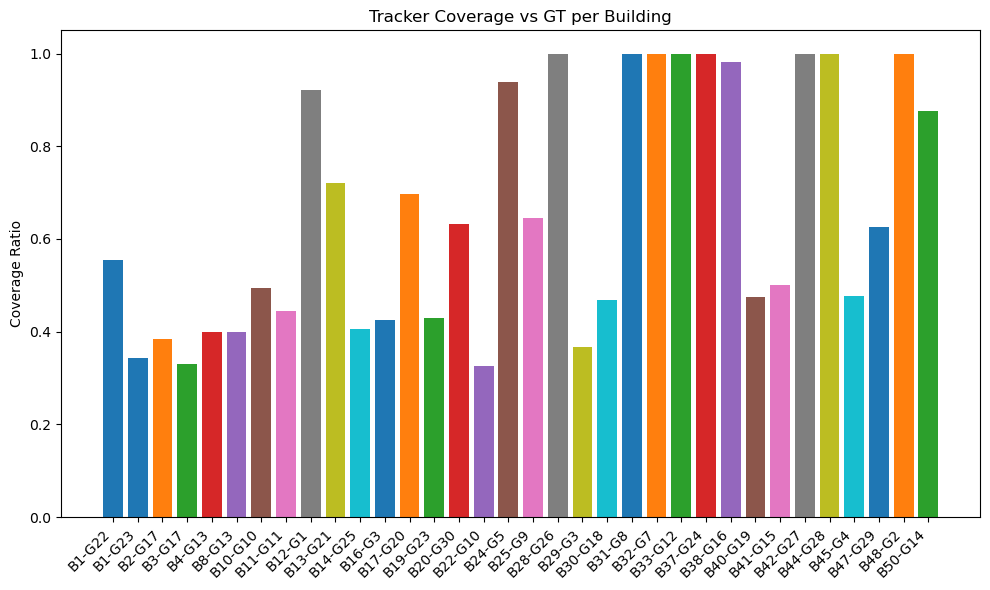

In [11]:
# --- Build summary table ---
rows = []
for building_id, linked_gt_ids in building_to_gt.items():
    for gt_id in linked_gt_ids:
        gt_data = gt_objects[gt_id]
        total_gt_frames = len(gt_data)
        match_frames = 0
        for frame, gt_box in gt_data:
            if frame in tracker_boxes_by_building[building_id]:
                for tb in tracker_boxes_by_building[building_id][frame]:
                    if iou(tb, gt_box) >= iou_thresh:
                        match_frames += 1
                        break
        coverage = match_frames / total_gt_frames if total_gt_frames > 0 else 0.0
        rows.append({
            "Building_ID": building_id,
            "GT_ID": gt_id,
            "Total_GT_Frames": total_gt_frames,
            "Matched_Frames": match_frames,
            "Coverage_Ratio": coverage
        })

df = pd.DataFrame(rows)

# Sort first
df_sorted = df.sort_values(by=["Building_ID", "Coverage_Ratio"], ascending=[True, False])

# Cast integer columns
int_cols = ["Building_ID", "GT_ID", "Total_GT_Frames", "Matched_Frames"]
df_sorted[int_cols] = df_sorted[int_cols].astype(int)

# Keep Coverage_Ratio as float (optional: round to 2 decimals for display)
df_sorted["Coverage_Ratio"] = df_sorted["Coverage_Ratio"].round(2)

# Transpose and display
display(df_sorted.T)


# --- Pretty print ---
# display(df.sort_values(by=["Building_ID", "Coverage_Ratio"], ascending=[True, False]).T)

# --- Plot bar graph ---
plt.figure(figsize=(10,6))
for building_id, group in df.groupby("Building_ID"):
    plt.bar(
        [f"B{building_id}-G{gt}" for gt in group["GT_ID"]],
        group["Coverage_Ratio"],
        label=f"Building {building_id}"
    )

# plt.axhline(0.3, color="red", linestyle="--", label="30% threshold")
plt.ylabel("Coverage Ratio")
plt.title("Tracker Coverage vs GT per Building")
plt.xticks(rotation=45, ha="right")
# plt.legend()
plt.tight_layout()

# --- Save image ---
output_path = os.path.join(output_dir, "tracker_coverage_building.png")
plt.savefig(output_path, dpi=400)
print(f"Bar graph saved to {output_path}")

plt.show()


### Coverage for IOU tracking comparison

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Building_ID,1.00,1.00,2.00,3.00,4.00,8.00,10.00,11.00,12.00,13.00,...,37.0,38.00,40.00,41.0,42.0,44.0,45.00,47.00,48.0,50.00
GT_ID,22.00,23.00,17.00,17.00,13.00,13.00,10.00,11.00,1.00,21.00,...,24.0,16.00,19.00,15.0,27.0,28.0,4.00,29.00,2.0,14.00
Total_GT_Frames,63.00,35.00,148.00,148.00,40.00,40.00,95.00,27.00,114.00,43.00,...,9.0,107.00,78.00,8.0,5.0,5.0,86.00,8.00,5.0,16.00
Matched_Frames,35.00,12.00,57.00,49.00,16.00,16.00,47.00,12.00,105.00,31.00,...,9.0,105.00,37.00,4.0,5.0,5.0,41.00,5.00,5.0,14.00
Coverage_Ratio,0.56,0.34,0.39,0.33,0.40,0.40,0.49,0.44,0.92,0.72,...,1.0,0.98,0.47,0.5,1.0,1.0,0.48,0.62,1.0,0.88
Coverage_Ratio_IOU,0.00,0.03,0.11,0.11,0.08,0.08,0.02,0.00,0.17,0.00,...,0.0,0.00,0.00,0.0,0.0,0.0,0.10,0.00,0.0,0.12


Bar graph saved to frames_8dir_turn/outputs/tracker_coverage_comparison.png


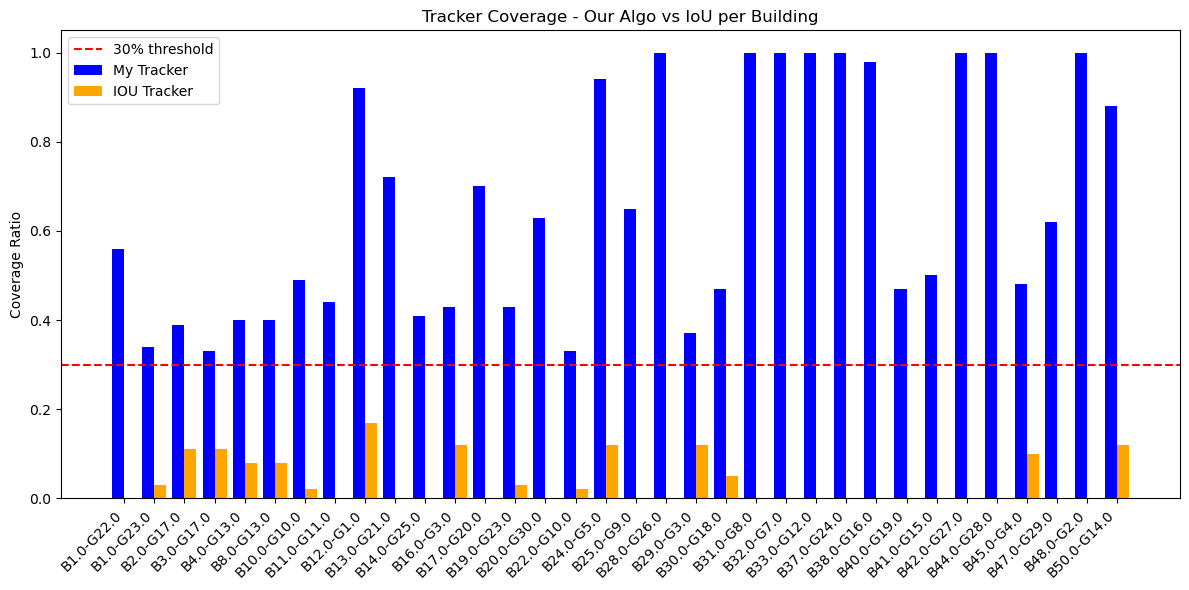

In [12]:
# --- Paths ---
iou_tracker_path = "frames_8dir_turn/validation/mot_eval/iou_algo/det.txt"

# --- Load IOU tracker in MOT format ---
iou_tracker_boxes_by_building = defaultdict(lambda: defaultdict(list))
with open(iou_tracker_path, "r") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) < 6:
            continue
        frame = int(parts[0])
        obj_id = int(parts[1])
        # Convert all coordinates to float
        x, y, w, h = map(float, parts[2:6])
        box = (x, y, w, h)
        for building_id in merged_buildings:
            iou_tracker_boxes_by_building[building_id][frame].append(box)


# --- Compute coverage for IOU tracker ---
iou_rows = [] 
for building_id, linked_gt_ids in building_to_gt.items():
    for gt_id in linked_gt_ids:
        gt_data = gt_objects[gt_id]
        total_gt_frames = len(gt_data)
        match_frames = 0
        for entry in gt_data:  # <- entry is (frame, (x,y,w,h))
            frame = entry[0]
            gt_box = entry[1]
            if frame in iou_tracker_boxes_by_building[building_id]:
                for tb in iou_tracker_boxes_by_building[building_id][frame]:
                    if iou(tb, gt_box) >= iou_thresh:
                        match_frames += 1
                        break

        coverage = match_frames / total_gt_frames if total_gt_frames > 0 else 0.0
        iou_rows.append({
            "Building_ID": building_id,
            "GT_ID": gt_id,
            "Matched_Frames_IOU": match_frames,
            "Coverage_Ratio_IOU": coverage
        })

iou_df = pd.DataFrame(iou_rows)

# --- Merge with your tracker coverage table ---
comparison_df = df.merge(
    iou_df[["Building_ID", "GT_ID", "Coverage_Ratio_IOU"]],
    on=["Building_ID", "GT_ID"]
)

# --- Round values for display ---
comparison_df[["Coverage_Ratio", "Coverage_Ratio_IOU"]] = comparison_df[["Coverage_Ratio", "Coverage_Ratio_IOU"]].round(2)
display(comparison_df.T)

# --- Plot side-by-side bar graph ---
plt.figure(figsize=(12,6))

# Create x-axis labels
x_labels = []
my_values = []
iou_values = []
for _, row in comparison_df.iterrows():
    label = f"B{row['Building_ID']}-G{row['GT_ID']}"
    x_labels.append(label)
    my_values.append(row['Coverage_Ratio'])
    iou_values.append(row['Coverage_Ratio_IOU'])

# Define bar positions
import numpy as np
x = np.arange(len(x_labels))
width = 0.4  # width of the bars

# Plot bars by algorithm
plt.bar(x - width/2, my_values, width, color='blue', label='My Tracker')
plt.bar(x + width/2, iou_values, width, color='orange', label='IOU Tracker')

plt.axhline(overlap_thresh, color="red", linestyle="--", label=f"{int(overlap_thresh*100)}% threshold")
plt.ylabel("Coverage Ratio")
plt.title("Tracker Coverage - Our Algo vs IoU per Building")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()

# --- Save image ---
output_path = os.path.join(output_dir, "tracker_coverage_comparison.png")
plt.savefig(output_path, dpi=400)
print(f"Bar graph saved to {output_path}")

plt.show()


### Calculating misdetections and Adjusted Coverage

In [13]:
# --- Setup ---
misdetection_dir = os.path.join(output_dir, "misdetections_with_masks_fixed")
os.makedirs(misdetection_dir, exist_ok=True)

# Plasma colormap: building = yellow (high end), background = purple (low end)
plasma = plt.cm.plasma
yellow_rgb = tuple((np.array(plasma(0.95)[:3]) * 255).astype(np.uint8))   # building = yellow
purple_rgb = tuple((np.array(plasma(0.05)[:3]) * 255).astype(np.uint8))   # background/others = purple

start_time = time.time()
misdet_summary = []

# --- Pre-index segments per building per frame (keep — speeds lookups) ---
print("Indexing building segments per frame...")
building_segments_per_frame = defaultdict(lambda: defaultdict(list))
for building_id, entries in merged_buildings.items():
    for entry_image, segment, _ in entries:
        # entry_image is image_name (string). Use as-is.
        building_segments_per_frame[building_id][entry_image].append(segment)
print("✓ Done indexing.\n")

# --- Main loop: iterate building -> GT pairs ---
for building_id, linked_gt_ids in building_to_gt.items():
    print(f"\n▶ Processing Building {building_id} with {len(linked_gt_ids)} linked GT(s)")
    for gt_idx, gt_id in enumerate(sorted(linked_gt_ids)):
        gt_data = gt_objects[gt_id]               # list of (frame, (x,y,w,h))
        total_gt_frames = len(gt_data)
        misdet_frames = 0
        frame_images = []
        processed_frames = 0

        print(f"  - GT {gt_id} ({gt_idx+1}/{len(linked_gt_ids)}), total GT frames: {total_gt_frames}")

        for idx, (frame, gt_box) in enumerate(gt_data):
            image_name = str(frame)
            mask_path = os.path.join(output_dir, image_name + "_mask.npy")
            if not os.path.exists(mask_path):
                # Mask missing: still count detection check (but warn) and skip visualization
                print(f"    ! mask missing for frame {image_name}, skipping visualization for this frame")
                continue

            processed_frames += 1
            mask_img_np = np.load(mask_path)

            # Check whether any tracker bbox overlaps this GT in this frame
            detected = False
            if frame in tracker_boxes_by_building[building_id]:
                for tb in tracker_boxes_by_building[building_id][frame]:
                    if iou(tb, gt_box) >= iou_thresh:
                        detected = True
                        break

            # Build overlay:
            # - default background/pixels -> purple
            # - tracked building segments in this frame -> yellow
            overlay = np.zeros((*mask_img_np.shape, 4), dtype=np.uint8)
            overlay[..., :3] = purple_rgb
            overlay[..., 3] = 150  # semi-transparent purple base

            # Overlay yellow for any segments that belong to this building in this image
            segments_here = building_segments_per_frame[building_id].get(image_name, [])
            if segments_here:
                for seg in segments_here:
                    overlay[mask_img_np == seg, :3] = yellow_rgb
                    overlay[mask_img_np == seg, 3] = 200

            # Compose with base image
            img_path = os.path.join('frames_8dir_turn','images', image_name + '.png')
            if not os.path.exists(img_path):
                print(f"    ! base image missing: {img_path}, skipping frame")
                continue
            base_img = Image.open(img_path).convert("RGBA")
            overlay_img = Image.fromarray(overlay, mode="RGBA")
            combined = Image.alpha_composite(base_img, overlay_img)
            draw = ImageDraw.Draw(combined)

            # If not detected -> red bbox (GT misdetection)
            if not detected:
                misdet_frames += 1
                x, y, w, h = gt_box
                draw.rectangle([x, y, x + w, y + h], outline=(255, 0, 0, 255), width=3)

            frame_images.append(combined)

            # Debug prints occasionally
            # if idx % 20 == 0:
            #     print(f"    • GT {gt_id} frame {idx+1}/{total_gt_frames} (image {image_name}), detected={detected}, segments_here={len(segments_here)}")

        # After iterating frames for this GT
        misdet_ratio = misdet_frames / total_gt_frames if total_gt_frames > 0 else 0.0

        # Save GIF if images exist
        if frame_images:
            gif_path = os.path.join(
                misdetection_dir,
                f"building_{building_id}_gt_{gt_id}_misdetections.gif"
            )
            frame_images[0].save(
                gif_path,
                save_all=True,
                append_images=frame_images[1:],
                optimize=True,
                duration=gif_duration,
                loop=0
            )
            print(f"  ✓ Saved GIF for Building {building_id}, GT {gt_id}: {gif_path} ({len(frame_images)} frames)")

        else:
            print(f"  - No visual frames saved for Building {building_id}, GT {gt_id} (maybe masks missing)")

        misdet_summary.append({
            "Building_ID": building_id,
            "GT_ID": gt_id,
            "Total_GT_Frames": total_gt_frames,
            "Misdetections": misdet_frames,
            "Misdetection_Ratio": misdet_ratio,
            "Processed_Frames": processed_frames
        })

# --- Timing + summary dataframe ---
elapsed = time.time() - start_time
print(f"\n✅ Completed misdetection visualizations. Elapsed time: {elapsed/60:.1f} minutes")

# --- Build summary dataframe ---
misdet_df = pd.DataFrame(misdet_summary)

# Merge with coverage results (contains Matched_Frames, Total_GT_Frames)
merged_summary = df_sorted.merge(
    misdet_df[["Building_ID", "GT_ID", "Misdetections"]],
    on=["Building_ID", "GT_ID"],
    how="left"
)

# Replace NaNs with 0 for safety
merged_summary["Misdetections"] = merged_summary["Misdetections"].fillna(0)

# --- Compute adjusted coverage ---
# Frames with no detection ("misdetections") are excluded from denominator
merged_summary["Effective_Frames"] = (
    merged_summary["Total_GT_Frames"] - merged_summary["Misdetections"]
).clip(lower=1)  # avoid division by zero

merged_summary["Adjusted_Coverage"] = (
    merged_summary["Matched_Frames"] / merged_summary["Effective_Frames"]
).round(3)


Indexing building segments per frame...
✓ Done indexing.


▶ Processing Building 1 with 2 linked GT(s)
  - GT 22 (1/2), total GT frames: 63
  ✓ Saved GIF for Building 1, GT 22: frames_8dir_turn/outputs/misdetections_with_masks_fixed\building_1_gt_22_misdetections.gif (63 frames)
  - GT 23 (2/2), total GT frames: 35
  ✓ Saved GIF for Building 1, GT 23: frames_8dir_turn/outputs/misdetections_with_masks_fixed\building_1_gt_23_misdetections.gif (35 frames)

▶ Processing Building 2 with 1 linked GT(s)
  - GT 17 (1/1), total GT frames: 148
    ! mask missing for frame 250, skipping visualization for this frame
    ! mask missing for frame 251, skipping visualization for this frame
    ! mask missing for frame 252, skipping visualization for this frame
    ! mask missing for frame 253, skipping visualization for this frame
    ! mask missing for frame 254, skipping visualization for this frame
    ! mask missing for frame 255, skipping visualization for this frame
    ! mask missing for frame

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
Building_ID,1.00,1.00,2.000,3.000,4.000,8.000,10.000,11.00,12.000,13.00,...,37.0,38.00,40.000,41.0,42.0,44.0,45.000,47.00,48.0,50.000
GT_ID,22.00,23.00,17.000,17.000,13.000,13.000,10.000,11.00,1.000,21.00,...,24.0,16.00,19.000,15.0,27.0,28.0,4.000,29.00,2.0,14.000
Total_GT_Frames,63.00,35.00,148.000,148.000,40.000,40.000,95.000,27.00,114.000,43.00,...,9.0,107.00,78.000,8.0,5.0,5.0,86.000,8.00,5.0,16.000
Matched_Frames,35.00,12.00,57.000,49.000,16.000,16.000,47.000,12.00,105.000,31.00,...,9.0,105.00,37.000,4.0,5.0,5.0,41.000,5.00,5.0,14.000
Coverage_Ratio,0.56,0.34,0.390,0.330,0.400,0.400,0.490,0.44,0.920,0.72,...,1.0,0.98,0.470,0.5,1.0,1.0,0.480,0.62,1.0,0.880
Misdetections,28.00,23.00,57.000,38.000,19.000,16.000,39.000,15.00,2.000,12.00,...,0.0,2.00,0.000,0.0,0.0,0.0,18.000,3.00,0.0,0.000
Effective_Frames,35.00,12.00,91.000,110.000,21.000,24.000,56.000,12.00,112.000,31.00,...,9.0,105.00,78.000,8.0,5.0,5.0,68.000,5.00,5.0,16.000
Adjusted_Coverage,1.00,1.00,0.626,0.445,0.762,0.667,0.839,1.00,0.938,1.00,...,1.0,1.00,0.474,0.5,1.0,1.0,0.603,1.00,1.0,0.875


Saved adjusted coverage plot to frames_8dir_turn/outputs/tracker_adjusted_coverage_excluding_misdet.png


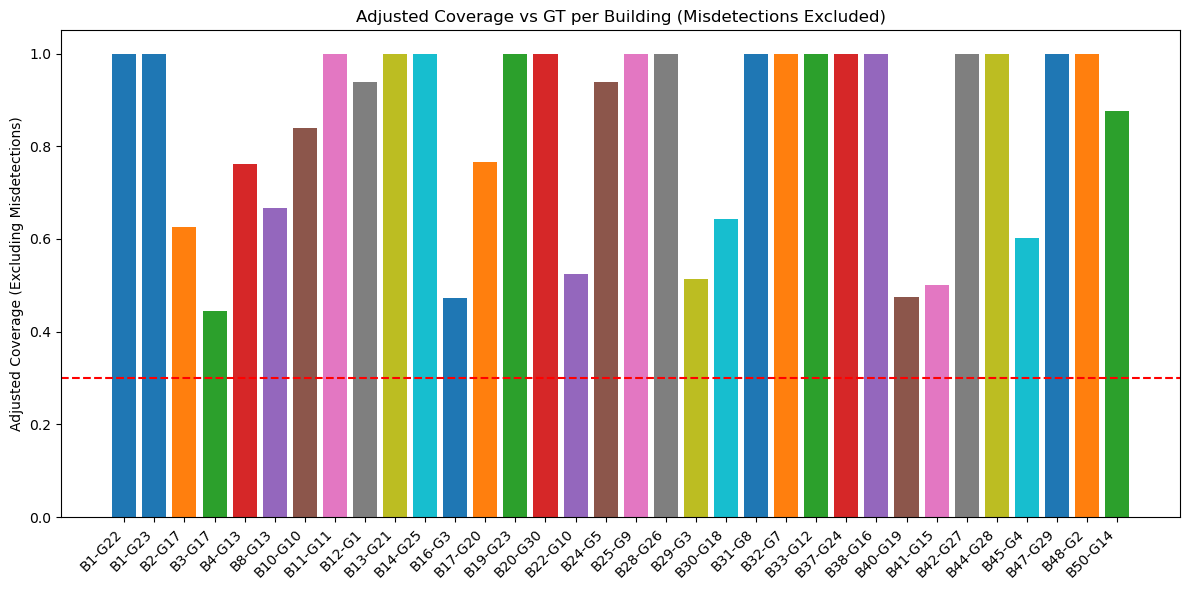

In [14]:
# --- Display ---
display(merged_summary.T)

# --- Plot adjusted coverage ---
plt.figure(figsize=(12, 6))
for building_id, group in merged_summary.groupby("Building_ID"):
    plt.bar(
        [f"B{building_id}-G{gt}" for gt in group["GT_ID"]],
        group["Adjusted_Coverage"],
        label=f"Building {building_id}"
    )

plt.axhline(overlap_thresh, color="red", linestyle="--", label=f"{int(overlap_thresh*100)}% threshold")
plt.ylabel("Adjusted Coverage (Excluding Misdetections)")
plt.title("Adjusted Coverage vs GT per Building (Misdetections Excluded)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

output_path = os.path.join(output_dir, "tracker_adjusted_coverage_excluding_misdet.png")
plt.savefig(output_path, dpi=400)
print(f"Saved adjusted coverage plot to {output_path}")
plt.show()

### Comparison of Coverage and Adjusted Coverage for both methods

Merging coverage tables...
Saved combined coverage comparison to frames_8dir_turn/outputs/tracker_coverage_comparison_adjusted.png


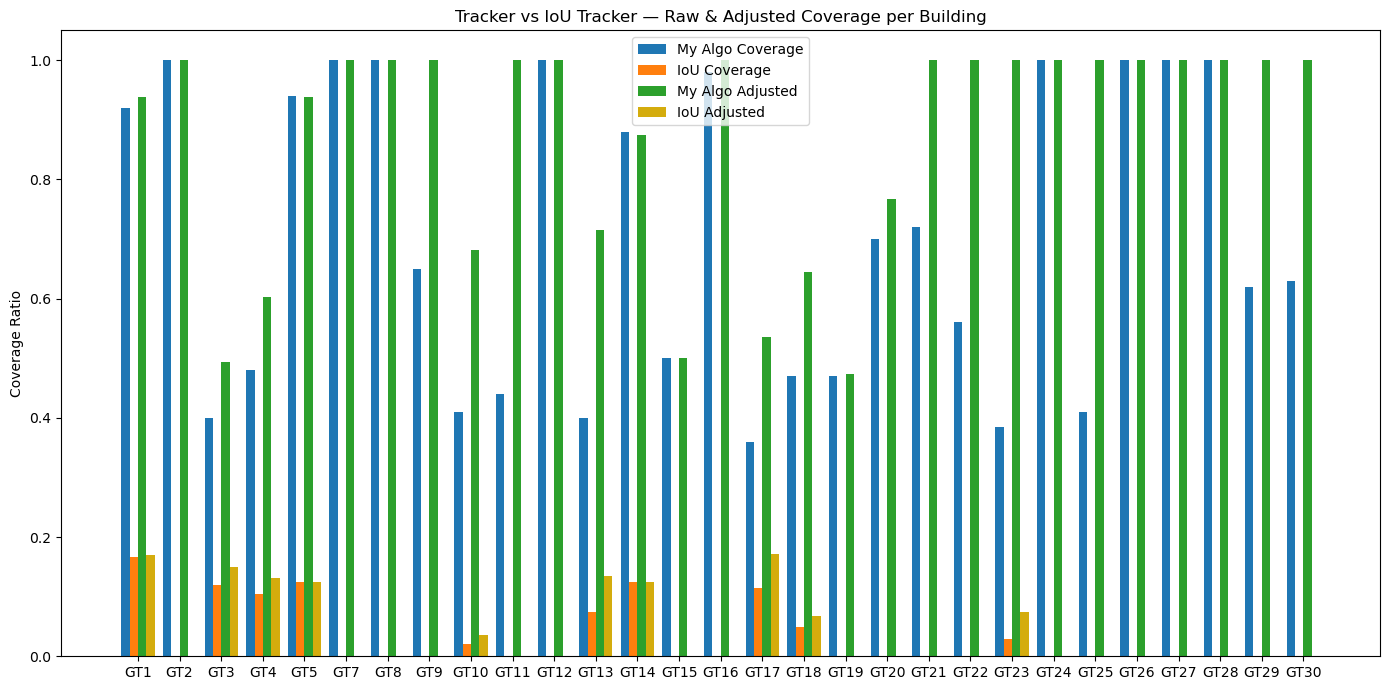

In [15]:
# --- Merge all coverage sources safely ---
print("Merging coverage tables...")

# Step 1: base = my tracker coverage
comparison_full = df_sorted.copy()

# Step 2: add IOU coverage
comparison_full = comparison_full.merge(
    iou_df[["Building_ID", "GT_ID", "Matched_Frames_IOU", "Coverage_Ratio_IOU"]],
    on=["Building_ID", "GT_ID"],
    how="left"
)

# Step 3: add misdetections (no Total_GT_Frames in misdet_df — take from df_sorted)
if "Total_GT_Frames" not in misdet_df.columns:
    print("Note: 'Total_GT_Frames' missing in misdet_df; using from df_sorted.")
misdet_cols = [c for c in misdet_df.columns if c in ["Building_ID", "GT_ID", "Misdetections"]]

comparison_full = comparison_full.merge(
    misdet_df[misdet_cols],
    on=["Building_ID", "GT_ID"],
    how="left"
)

comparison_full["Misdetections"] = comparison_full["Misdetections"].fillna(0)
comparison_full["Total_GT_Frames"] = comparison_full["Total_GT_Frames"].fillna(1)

# --- Compute adjusted coverage for both algorithms ---
comparison_full["My_Adjusted_Coverage"] = (
    comparison_full["Matched_Frames"] /
    (comparison_full["Total_GT_Frames"] - comparison_full["Misdetections"]).clip(lower=1)
).round(3)

comparison_full["IOU_Adjusted_Coverage"] = (
    comparison_full["Matched_Frames_IOU"] /
    (comparison_full["Total_GT_Frames"] - comparison_full["Misdetections"]).clip(lower=1)
).round(3)

# # --- Sanity check ---
# print("✓ Merge complete. Columns available:")
# print(list(comparison_full.columns))
# print("Sample rows:")
# display(comparison_full.head(3).T)

# --- Plot grouped bar chart per building ---
plt.figure(figsize=(14, 7))
bar_width = 0.2

# Average metrics per building (across GTs)
building_means = (
    comparison_full.groupby("GT_ID")[
        ["Coverage_Ratio", "Coverage_Ratio_IOU", "My_Adjusted_Coverage", "IOU_Adjusted_Coverage"]
    ].mean().reset_index()
)


x = np.arange(len(building_means))
plt.bar(x - 1.5*bar_width, building_means["Coverage_Ratio"], width=bar_width, label="My Algo Coverage", color="#1f77b4")
plt.bar(x - 0.5*bar_width, building_means["Coverage_Ratio_IOU"], width=bar_width, label="IoU Coverage", color="#ff7f0e")
plt.bar(x + 0.5*bar_width, building_means["My_Adjusted_Coverage"], width=bar_width, label="My Algo Adjusted", color="#2ca02c")
plt.bar(x + 1.5*bar_width, building_means["IOU_Adjusted_Coverage"], width=bar_width, label="IoU Adjusted", color="#d4ac0d")

# plt.axhline(0.2, color="red", linestyle="--", label="20% threshold")
plt.xticks(x, [f"GT{g}" for g in building_means["GT_ID"]], rotation=0)
plt.ylabel("Coverage Ratio")
plt.title("Tracker vs IoU Tracker — Raw & Adjusted Coverage per Building")
plt.legend()
plt.tight_layout()

output_path = os.path.join(output_dir, "tracker_coverage_comparison_adjusted.png")
plt.savefig(output_path, dpi=400)
print(f"Saved combined coverage comparison to {output_path}")
plt.show()


####  Add third tracker: SAM2+MOTRv2 

3-way comparison plot saved to frames_8dir_turn/outputs/tracker_coverage_comparison_all3.png


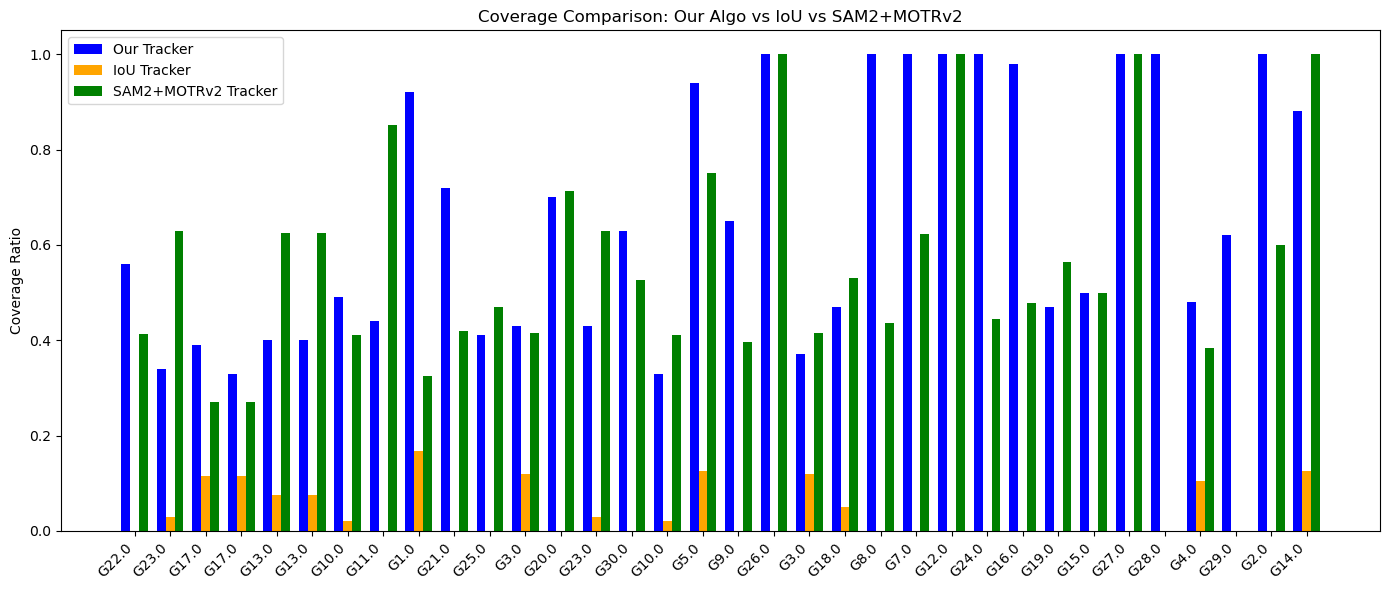

In [16]:
# ================================
# SAM2+MOTRv2 COVERAGE (Option C)
# IoU >= iou_thresh  AND  IoG >= iog_thresh
# ================================

iog_thresh = 0.30  # <-- YOU CAN ADJUST THIS (recommended 0.3–0.4)

sam2_motrv2_path = r'frames_8dir_turn\validation\mot_eval\SAM2+MOTRv2\det.txt'
# --- Helper: compute IoG ---
def iog(pred_box, gt_box):
    """
    Intersection-over-GT:
    IoG = intersection_area / gt_area
    """
    px, py, pw, ph = pred_box
    gx, gy, gw, gh = gt_box

    # Compute overlap rectangle
    xA = max(px, gx)
    yA = max(py, gy)
    xB = min(px + pw, gx + gw)
    yB = min(py + ph, gy + gh)

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    gt_area = max(1e-6, gw * gh)  # avoid divide-by-zero
    return inter_area / gt_area


# --- Load SAM2+MOTRv2 tracking (global IDs) ---
sam2_motrv2_boxes_by_id = defaultdict(lambda: defaultdict(list))  # tracker_id -> frame -> [box]

with open(sam2_motrv2_path, "r") as f:
    for line in f:
        parts = line.strip().split(",")
        if len(parts) < 6:
            continue
        frame = int(parts[0])
        tracker_id = int(parts[1])
        x, y, w, h = map(float, parts[2:6])
        sam2_motrv2_boxes_by_id[tracker_id][frame].append((x, y, w, h))


# --- Compute coverage ---
sam2_motrv2_rows = []

for building_id, linked_gt_ids in building_to_gt.items():

    for gt_id in linked_gt_ids:

        gt_data = gt_objects[gt_id]  # list of (frame, (x,y,w,h))
        total_gt_frames = len(gt_data)

        if total_gt_frames == 0:
            sam2_motrv2_rows.append({
                "Building_ID": building_id,
                "GT_ID": gt_id,
                "Best_Tracker_ID_SAM2_MOTRv2": -1,
                "Coverage_Ratio_SAM2_MOTRv2": 0.0,
                "Matched_Frames_SAM2_MOTRv2": 0
            })
            continue

        # Per-tracker matched-frame count
        tracker_match_counts = defaultdict(int)

        for frame, gt_box in gt_data:

            # Check each tracker ID that has boxes in this frame
            for tracker_id, tracker_frames in sam2_motrv2_boxes_by_id.items():

                if frame not in tracker_frames:
                    continue

                # Check all detections from that tracker in this frame
                for pred_box in tracker_frames[frame]:

                    # Must satisfy BOTH IoU and IoG
                    if iou(pred_box, gt_box) >= iou_thresh and iog(pred_box, gt_box) >= iog_thresh:
                        tracker_match_counts[tracker_id] += 1
                        break  # only count once per tracker per frame

        # Pick tracker ID with best coverage
        best_tracker_id = -1
        best_coverage = 0.0
        best_matches = 0

        for t_id, match_count in tracker_match_counts.items():
            cov = match_count / total_gt_frames
            if cov > best_coverage:
                best_coverage = cov
                best_tracker_id = t_id
                best_matches = match_count

        sam2_motrv2_rows.append({
            "Building_ID": building_id,
            "GT_ID": gt_id,
            "Best_Tracker_ID_SAM2_MOTRv2": best_tracker_id,
            "Coverage_Ratio_SAM2_MOTRv2": round(best_coverage, 3),
            "Matched_Frames_SAM2_MOTRv2": best_matches
        })

sam2_motrv2_df = pd.DataFrame(sam2_motrv2_rows)


# --- Merge into comparison_full ---
comparison_full = comparison_full.merge(
    sam2_motrv2_df,
    on=["Building_ID", "GT_ID"],
    how="left"
)

# Fill missing
comparison_full["Coverage_Ratio_SAM2_MOTRv2"] = (
    comparison_full["Coverage_Ratio_SAM2_MOTRv2"].fillna(0.0)
)
comparison_full["Matched_Frames_SAM2_MOTRv2"] = (
    comparison_full["Matched_Frames_SAM2_MOTRv2"].fillna(0).astype(int)
)

# display(comparison_full.T)


# ================================
# PLOT — 3 tracker comparison
# ================================
plt.figure(figsize=(14, 6))

x_labels = []
my_values = []
iou_values = []
sam2_values = []

for _, row in comparison_full.iterrows():
    x_labels.append(f"G{row['GT_ID']}")
    my_values.append(row["Coverage_Ratio"])
    iou_values.append(row["Coverage_Ratio_IOU"])
    sam2_values.append(row["Coverage_Ratio_SAM2_MOTRv2"])

x = np.arange(len(x_labels))
width = 0.25

plt.bar(x - width, my_values, width, label='Our Tracker', color='blue')
plt.bar(x, iou_values, width, label='IoU Tracker', color='orange')
plt.bar(x + width, sam2_values, width, label='SAM2+MOTRv2 Tracker', color='green')

# plt.axhline(overlap_thresh, color="red", linestyle="--",
#            label=f"{int(overlap_thresh*100)}% threshold")

plt.ylabel("Coverage Ratio")
plt.title("Coverage Comparison: Our Algo vs IoU vs SAM2+MOTRv2")
plt.xticks(x, x_labels, rotation=45, ha="right")
plt.legend()
plt.tight_layout()

output_path = os.path.join(output_dir, "tracker_coverage_comparison_all3.png")
plt.savefig(output_path, dpi=400)
print(f"3-way comparison plot saved to {output_path}")

plt.show()


Computing adjusted coverage for: Our Tracker, IoU Tracker, SAM2+MOTRv2

✓ Added SAM2_MOTRv2 misdetections.

✓ Adjusted coverage computed.

Saved adjusted 3-way tracker comparison to frames_8dir_turn/outputs/tracker_adjusted_coverage_comparison_all3.png


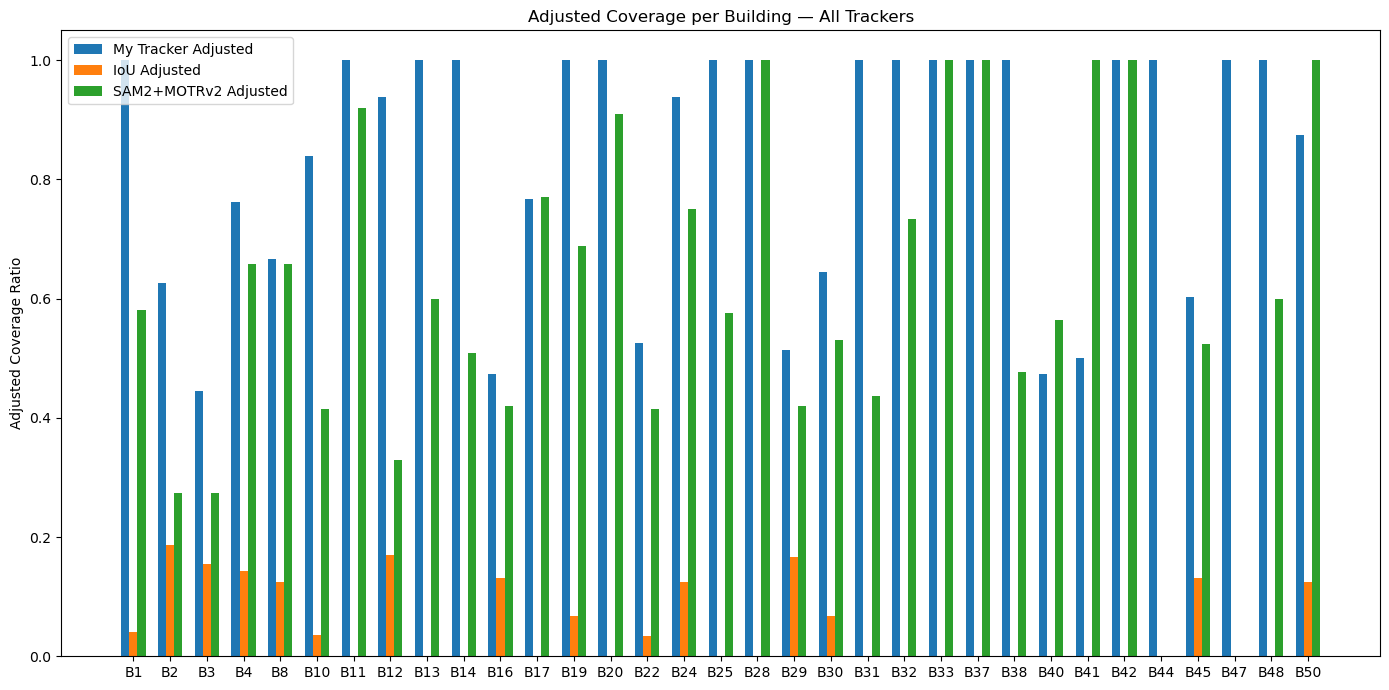

In [17]:
# ============================================
# ADJUSTED COVERAGE FOR ALL 3 TRACKERS
# ============================================

print("Computing adjusted coverage for: Our Tracker, IoU Tracker, SAM2+MOTRv2\n")
# ============================================
# COMPUTE MISDETECTIONS FOR SAM2+MOTRv2
# ============================================

sam2_mis_rows = []

for building_id, linked_gt_ids in building_to_gt.items():
    for gt_id in linked_gt_ids:

        gt_data = gt_objects[gt_id]  # list of (frame, (x,y,w,h))
        total_gt_frames = len(gt_data)

        missed = 0  # misdetections

        for frame, gt_box in gt_data:

            detected = False

            # Check all tracker IDs in this frame
            for tracker_id, tracker_frames in sam2_motrv2_boxes_by_id.items():

                if frame not in tracker_frames:
                    continue

                for pred_box in tracker_frames[frame]:

                    # Must match IoU + IoG like coverage
                    if iou(pred_box, gt_box) >= iou_thresh and iog(pred_box, gt_box) >= iog_thresh:
                        detected = True
                        break

                if detected:
                    break

            if not detected:
                missed += 1

        sam2_mis_rows.append({
            "Building_ID": building_id,
            "GT_ID": gt_id,
            "Misdetections_SAM2_MOTRv2": missed
        })

sam2_mis_df = pd.DataFrame(sam2_mis_rows)

# Merge into comparison_full
comparison_full = comparison_full.merge(
    sam2_mis_df,
    on=["Building_ID", "GT_ID"],
    how="left"
)

comparison_full["Misdetections_SAM2_MOTRv2"] = comparison_full["Misdetections_SAM2_MOTRv2"].fillna(0).astype(int)

print("✓ Added SAM2_MOTRv2 misdetections.\n")
# display(comparison_full.head(10).T)

# Ensure misdetection columns exist
comparison_full["Misdetections"] = comparison_full["Misdetections"].fillna(0)
comparison_full["Misdetections_SAM2_MOTRv2"] = comparison_full["Misdetections_SAM2_MOTRv2"].fillna(0)

# Ensure total GT frames is present
comparison_full["Total_GT_Frames"] = comparison_full["Total_GT_Frames"].fillna(0)

# -----------------------------
# Adjusted coverage per tracker
# -----------------------------

# OUR tracker
comparison_full["My_Adjusted_Coverage"] = (
    comparison_full["Matched_Frames"] /
    (comparison_full["Total_GT_Frames"] - comparison_full["Misdetections"])
).replace([float("inf"), -float("inf")], 0).fillna(0)

# IOU tracker
comparison_full["IOU_Adjusted_Coverage"] = (
    comparison_full["Matched_Frames_IOU"] /
    (comparison_full["Total_GT_Frames"] - comparison_full["Misdetections"])
).replace([float("inf"), -float("inf")], 0).fillna(0)

# SAM2+MOTRv2 tracker (uses its OWN misdetections!)
comparison_full["SAM2_MOTRv2_Adjusted_Coverage"] = (
    comparison_full["Matched_Frames_SAM2_MOTRv2"] /
    (comparison_full["Total_GT_Frames"] - comparison_full["Misdetections_SAM2_MOTRv2"])
).replace([float("inf"), -float("inf")], 0).fillna(0)

# Round for display (raw values are still in memory)
comparison_full["My_Adjusted_Coverage"] = comparison_full["My_Adjusted_Coverage"].round(3)
comparison_full["IOU_Adjusted_Coverage"] = comparison_full["IOU_Adjusted_Coverage"].round(3)
comparison_full["SAM2_MOTRv2_Adjusted_Coverage"] = comparison_full["SAM2_MOTRv2_Adjusted_Coverage"].round(3)

print("✓ Adjusted coverage computed.\n")

# ----------------------------------
# Display a clean subset for sanity
# ----------------------------------

cols_to_show = [
    "Building_ID", "GT_ID", "Total_GT_Frames",
    "Matched_Frames", "My_Adjusted_Coverage",
    "Matched_Frames_IOU", "IOU_Adjusted_Coverage",
    "Matched_Frames_SAM2_MOTRv2", "Misdetections_SAM2_MOTRv2",
    "SAM2_MOTRv2_Adjusted_Coverage"
]

# display(comparison_full[cols_to_show].T)

# ============================================
# Plot per-building averages (optional)
# ============================================

plt.figure(figsize=(14, 7))
bar_width = 0.22

building_means = (
    comparison_full.groupby("Building_ID")[
        ["My_Adjusted_Coverage",
         "IOU_Adjusted_Coverage",
         "SAM2_MOTRv2_Adjusted_Coverage"]
    ].mean().reset_index()
)

x = np.arange(len(building_means))

plt.bar(x - bar_width, building_means["My_Adjusted_Coverage"], width=bar_width,
        label="My Tracker Adjusted", color="#1f77b4")

plt.bar(x, building_means["IOU_Adjusted_Coverage"], width=bar_width,
        label="IoU Adjusted", color="#ff7f0e")

plt.bar(x + bar_width, building_means["SAM2_MOTRv2_Adjusted_Coverage"], width=bar_width,
        label="SAM2+MOTRv2 Adjusted", color="#2ca02c")

# plt.axhline(0.2, color="red", linestyle="--", label="20% threshold")
plt.xticks(x, [f"B{b}" for b in building_means["Building_ID"]])
plt.ylabel("Adjusted Coverage Ratio")
plt.title("Adjusted Coverage per Building — All Trackers")
plt.legend()
plt.tight_layout()

output_path = os.path.join(output_dir, "tracker_adjusted_coverage_comparison_all3.png")
plt.savefig(output_path, dpi=400)
print(f"Saved adjusted 3-way tracker comparison to {output_path}")

plt.show()


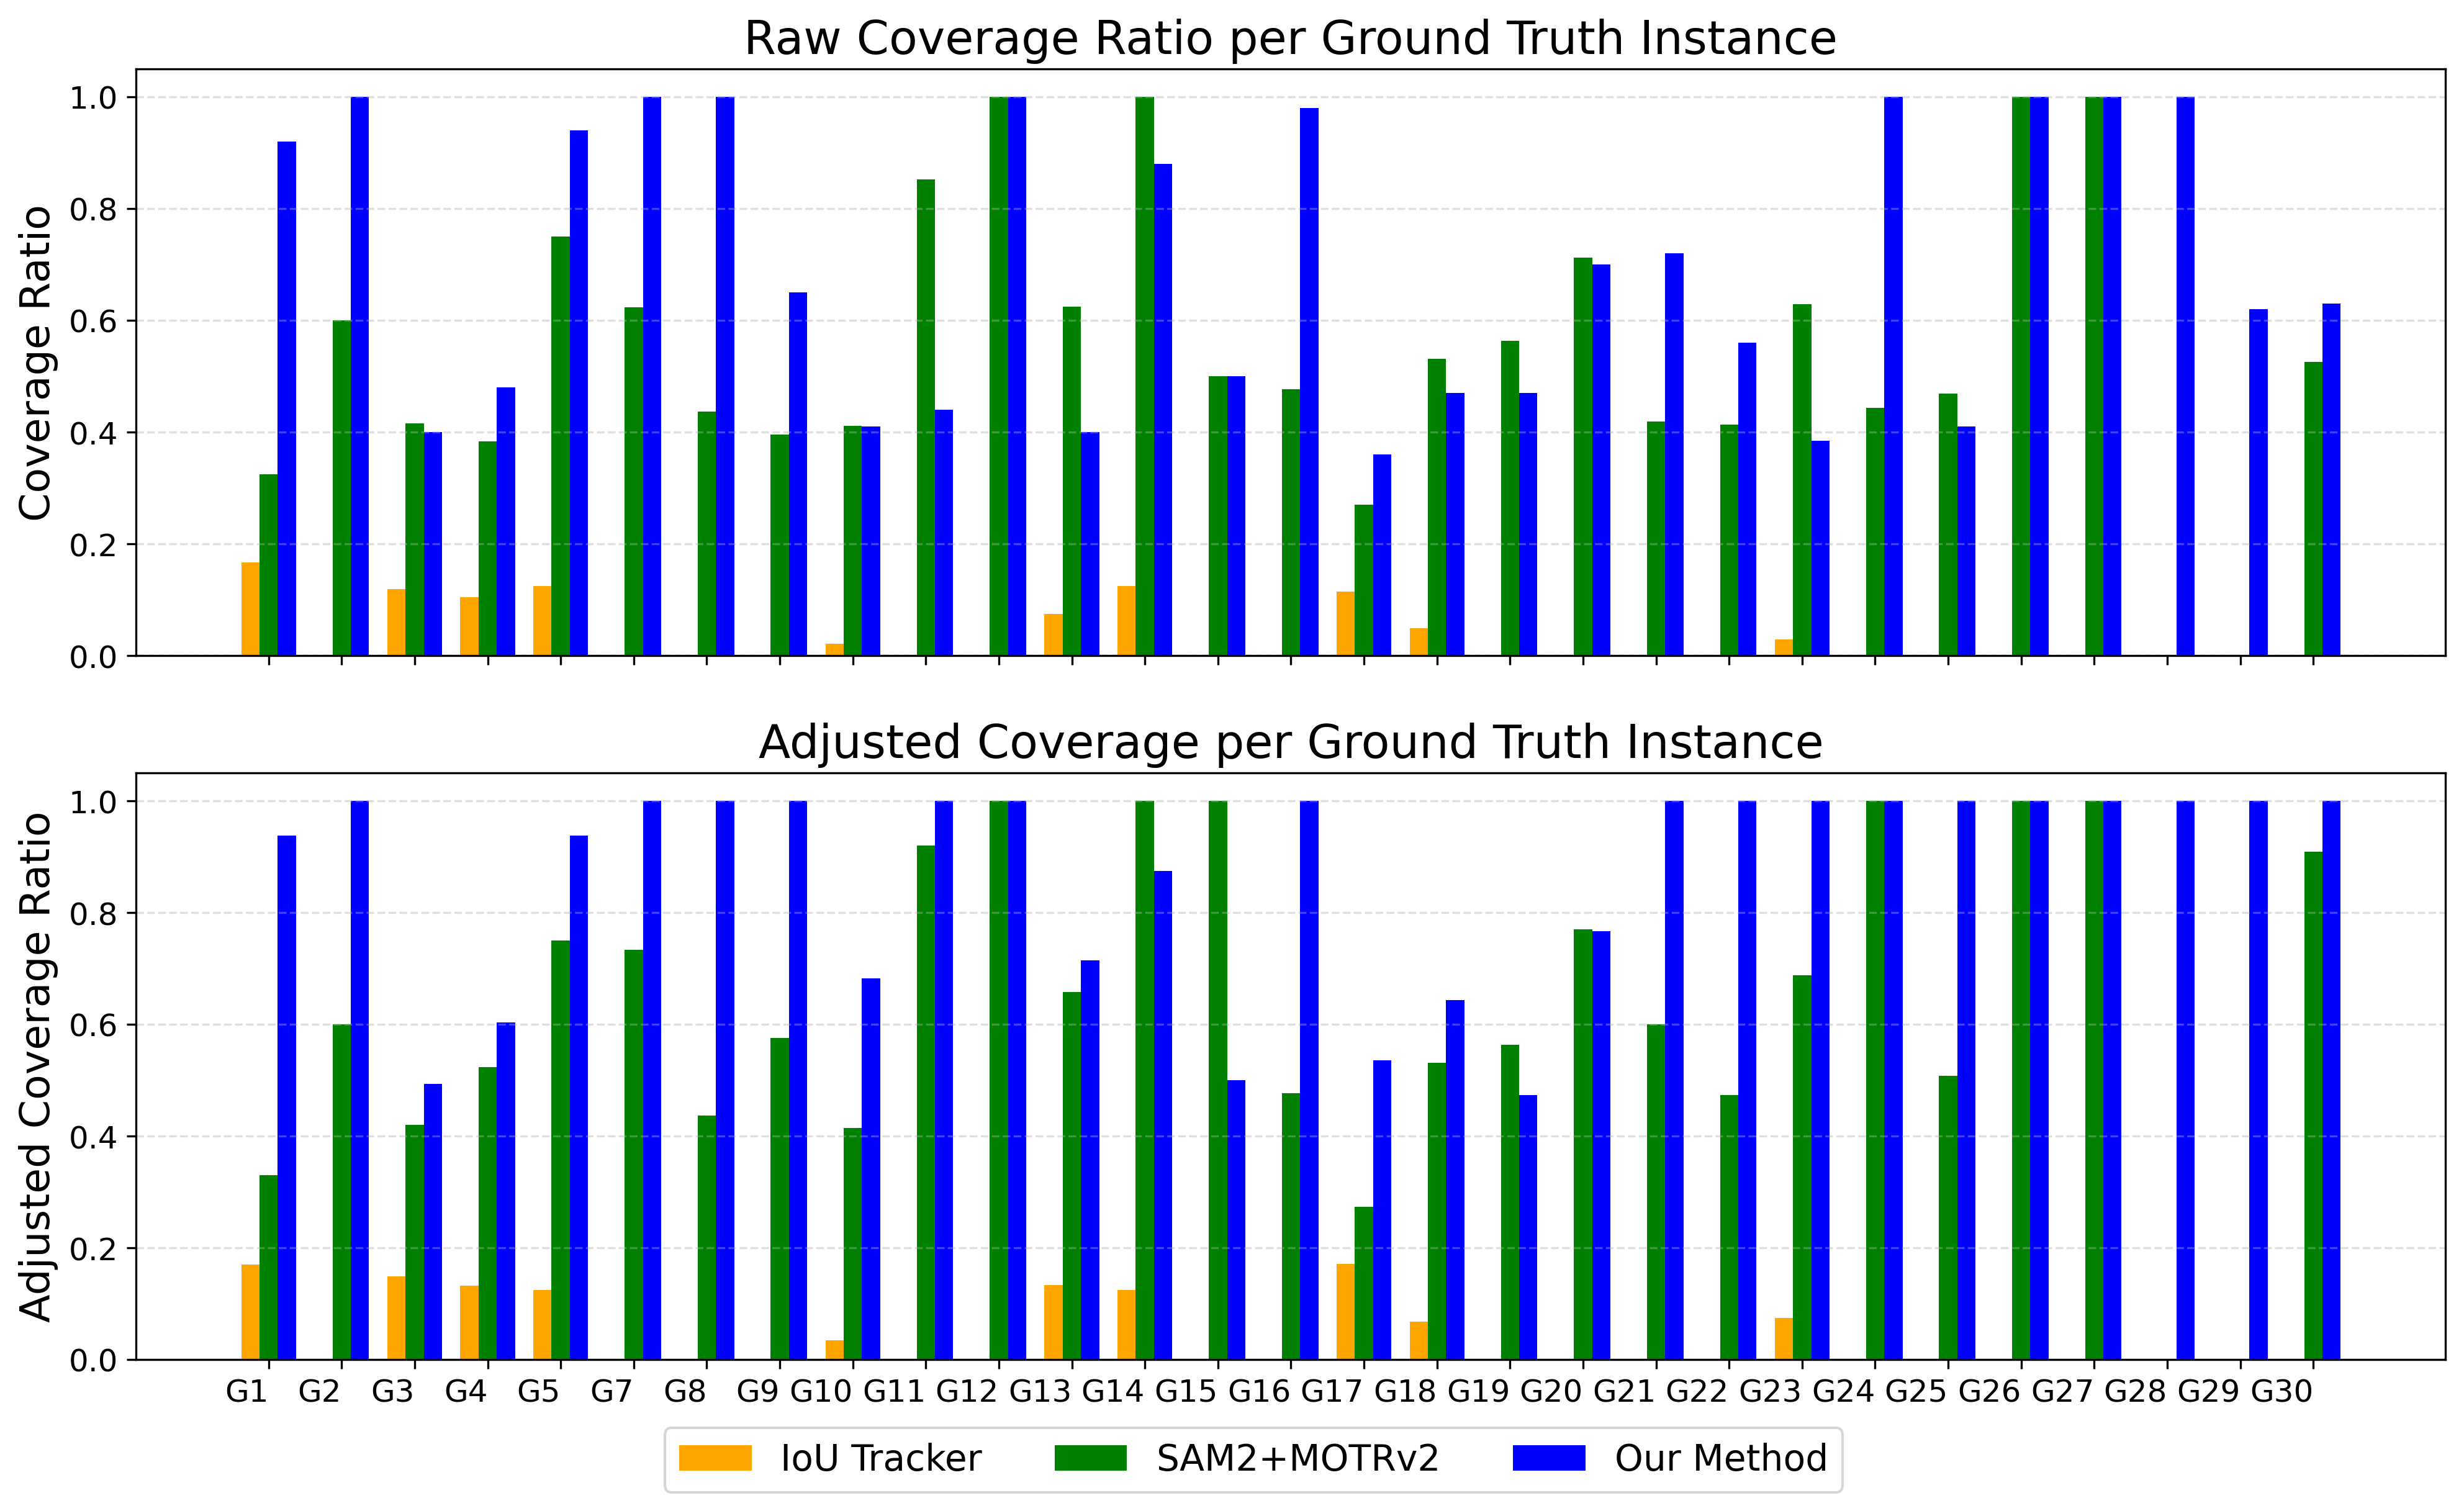

Saved shared-x-axis comparison figure to frames_8dir_turn/outputs/tracker_coverage_shared_xaxis.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------
# Prepare GT_ID-based index for both plots
# ------------------------------------------------------
gt_ids = sorted(comparison_full["GT_ID"].unique())
x = np.arange(len(gt_ids))
width = 0.25

# Build dictionaries indexed by GT_ID to guarantee alignment
raw_iou = comparison_full.groupby("GT_ID")["Coverage_Ratio_IOU"].mean().reindex(gt_ids).fillna(0)
raw_sam2 = comparison_full.groupby("GT_ID")["Coverage_Ratio_SAM2_MOTRv2"].mean().reindex(gt_ids).fillna(0)
raw_my  = comparison_full.groupby("GT_ID")["Coverage_Ratio"].mean().reindex(gt_ids).fillna(0)

adj_iou = comparison_full.groupby("GT_ID")["IOU_Adjusted_Coverage"].mean().reindex(gt_ids).fillna(0)
adj_sam2 = comparison_full.groupby("GT_ID")["SAM2_MOTRv2_Adjusted_Coverage"].mean().reindex(gt_ids).fillna(0)
adj_my   = comparison_full.groupby("GT_ID")["My_Adjusted_Coverage"].mean().reindex(gt_ids).fillna(0)

x_labels = [f"G{int(g)}" for g in gt_ids]

# ------------------------------------------------------
# Journal-quality style
# ------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 18,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 14,
    "figure.dpi": 300
})

# ------------------------------------------------------
# TWO SUBPLOTS — SHARED X AXIS
# ------------------------------------------------------
fig, axs = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# ------------------------------------------------------
# SUBPLOT 1 — Raw Coverage
# ------------------------------------------------------
axs[0].bar(x - width, raw_iou, width, label="IoU Tracker", color="orange")
axs[0].bar(x,         raw_sam2, width, label="SAM2+MOTRv2", color="green")
axs[0].bar(x + width, raw_my,  width, label="Our Method", color="blue")

axs[0].set_ylabel("Coverage Ratio")
axs[0].set_title("Raw Coverage Ratio per Ground Truth Instance")
axs[0].grid(axis='y', linestyle='--', alpha=0.4)

# ------------------------------------------------------
# SUBPLOT 2 — Adjusted Coverage
# ------------------------------------------------------
axs[1].bar(x - width, adj_iou, width, color="orange")
axs[1].bar(x,         adj_sam2, width, color="green")
axs[1].bar(x + width, adj_my, width, color="blue")

# axs[1].axhline(0.2, color="red", linestyle="--", linewidth=1)
axs[1].set_ylabel("Adjusted Coverage Ratio")
axs[1].set_title("Adjusted Coverage per Ground Truth Instance")
axs[1].grid(axis='y', linestyle='--', alpha=0.4)
axs[1].set_xticks(x)
axs[1].set_xticklabels(x_labels, ha="right")

# ------------------------------------------------------
# SHARED LEGEND BELOW BOTH SUBPLOTS
# ------------------------------------------------------
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center",
           ncol=3,
           frameon=True,
           bbox_to_anchor=(0.5, 0.02))

# fig.subplots_adjust(bottom=0.18, hspace=0.25)

output_path = os.path.join(output_dir, "tracker_coverage_shared_xaxis.png")
fig.savefig(output_path, dpi=400, bbox_inches='tight')
plt.show()

print(f"Saved shared-x-axis comparison figure to {output_path}")


In [31]:
# --- Compute averages across all GTs ---
avg_my_cov  = comparison_full["Coverage_Ratio"].mean()
avg_iou_cov = comparison_full["Coverage_Ratio_IOU"].mean()
avg_sam2_cov = comparison_full["Coverage_Ratio_SAM2_MOTRv2"].mean()

avg_my_adj  = comparison_full["My_Adjusted_Coverage"].mean()
avg_iou_adj = comparison_full["IOU_Adjusted_Coverage"].mean()
avg_sam2_adj = comparison_full["SAM2_MOTRv2_Adjusted_Coverage"].mean()

print("\n===== AVERAGE COVERAGE SUMMARY =====")
print(f"My Algo Coverage (raw):          {avg_my_cov:.3f}")
print(f"IoU Tracker Coverage (raw):      {avg_iou_cov:.3f}")
print(f"SAM2+MOTRv2 Coverage (raw):      {avg_sam2_cov:.3f}")
print(f"My Algo Adjusted Coverage:       {avg_my_adj:.3f}")
print(f"IoU Tracker Adjusted Coverage:   {avg_iou_adj:.3f}")
print(f"SAM2+MOTRv2 Adjusted Coverage:   {avg_sam2_adj:.3f}")

# --- Optional: per-building averages ---
per_building_avg = (
    comparison_full.groupby("Building_ID")[
        ["Coverage_Ratio",
         "Coverage_Ratio_IOU",
         "Coverage_Ratio_SAM2_MOTRv2",
         "My_Adjusted_Coverage",
         "IOU_Adjusted_Coverage",
         "SAM2_MOTRv2_Adjusted_Coverage"]
    ].mean().round(3)
)

# display(per_building_avg)

# --- Save ---
csv_path = os.path.join(output_dir, "coverage_summary_averages.csv")
per_building_avg.to_csv(csv_path)
print(f"\nSaved per-building averages to {csv_path}")
with open('comparison_full_dict.pkl', 'wb') as f:
    pickle.dump(comparison_full, f)



===== AVERAGE COVERAGE SUMMARY =====
My Algo Coverage (raw):          0.655
IoU Tracker Coverage (raw):      0.038
SAM2+MOTRv2 Coverage (raw):      0.533
My Algo Adjusted Coverage:       0.841
IoU Tracker Adjusted Coverage:   0.051
SAM2+MOTRv2 Adjusted Coverage:   0.606

Saved per-building averages to frames_8dir_turn/outputs/coverage_summary_averages.csv


In [21]:
file_path = 'comparison_full_dict.pkl'

if os.path.exists(file_path):
    with open(file_path, 'rb') as f:
        comparison_full = pickle.load(f)
    print("Loaded successfully.")
else:
    # Initialize an empty dict or handle the missing file
    comparison_full = {}
    print("File not found. Initialized empty dictionary.")